# Transformers y Modelos de Lenguaje Grande (LLM)
## Clasificación de intenciones bancarias con DistilRoBERTa y explicación de errores con Falcon-7b-instruct

**Asignatura:** Sistemas Cognitivos Artificiales · Maestría en Inteligencia Artificial · UNIR México  
**Actividad:** 2 (individual)  
**Autor:** Adonai Samael Hernández Mata  
**Fecha:** septiembre de 2026

---

### Objetivo

1. Hacer un **análisis exploratorio** de las 13 083 consultas bancarias de `PolyAI/banking77`.
2. Afinar (*fine-tuning*) el Transformer preentrenado **DistilRoBERTa** para clasificar cada
   consulta en una de **77 intenciones**, y evaluarlo con accuracy, matriz de confusión y
   precision/recall/F1 por clase.
3. Diseñar y **calibrar un prompt** para `tiiuae/falcon-7b-instruct` que explique, en máximo dos
   oraciones, por qué el clasificador se equivocó en 20 consultas, controlando las
   alucinaciones con la temperatura, la longitud de respuesta y la estructura del prompt.

### Índice

0. Entorno de ejecución
1. Carga del dataset
2. Análisis exploratorio de datos
3. Clasificación con DistilRoBERTa (3.6 causas con base en el EDA · 3.8 mejoras técnicas propuestas)
4. Explicación de errores con Falcon-7b-instruct (4.4 calibración de decodificación · 4.5 calibración de la estructura del prompt)
5. Conclusiones generales
6. Referencias
7. Anexo: exportación de resultados

## 0. Entorno de ejecución

El notebook detecta el acelerador disponible y se adapta:

| Entorno | Clasificador | Falcon-7b-instruct |
|---|---|---|
| Google Colab (GPU T4) | CUDA | cuantizado a 4 bits con `bitsandbytes` (≈ 4 GB de VRAM) |
| Apple Silicon (esta ejecución) | MPS | `float16` en memoria unificada (≈ 14 GB) |
| Solo CPU | CPU | `bfloat16` en CPU (lento, pero funciona) |

Para Colab basta con descomentar la celda de instalación. Se fija la semilla `42` en todas las
librerías para que los resultados sean reproducibles.

**Requisitos de hardware del enunciado y cómo se atienden:**

- *Colab (GPU T4, ≥ 15 GB libres para Falcon-7b)*: la VRAM se verifica con `!nvidia-smi`; además, la
  celda 4.1 imprime la memoria que ocupa Falcon tras cargarlo, en cualquier acelerador. Con la
  cuantización a 4 bits NF4 (Dettmers et al., 2023) Falcon ocupa bastante menos que en `float16`.
- *Esta ejecución (Apple Silicon, memoria unificada)*: Falcon-7b se carga en `float16`; la celda 4.1
  deja constancia de la memoria medida.
- *Aviso de NumPy del enunciado* (`ValueError: Unable to avoid copy…` → reinstalar `NumPy<=1.24.3`):
  **no se presentó** con las versiones de esta ejecución (las imprime la celda siguiente); si aparece en
  Colab con versiones antiguas de `datasets`, la solución es la del enunciado.

In [1]:
# En Google Colab, descomentar para instalar las dependencias y verificar la GPU:
# !pip install -q "transformers>=4.56" accelerate datasets scikit-learn nltk wordcloud seaborn bitsandbytes
# !nvidia-smi          # comprobar GPU T4 y ≥ 15 GB de VRAM libres antes de cargar Falcon-7b
# Solo si aparece "ValueError: Unable to avoid copy while creating an array":
# !pip install -q "numpy<=1.24.3"

In [2]:
# ── Librerías ────────────────────────────────────────────────────────────────
import gc, json, os, re, time, random, warnings
from collections import Counter
from pathlib import Path

# Cálculo numérico, tablas, gráficas y modelos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers
import datasets
from IPython.display import display, Markdown

# Salida limpia: sin avisos ni barras de progreso de Hugging Face (ensucian el PDF), tablas completas
warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
transformers.logging.set_verbosity_error()
transformers.utils.logging.disable_progress_bar()
datasets.disable_progress_bars()
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
transformers.set_seed(SEED)

# ── Dispositivo ─────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

# ── Rutas del proyecto ──────────────────────────────────────────────────────
# Funciona igual si el notebook se abre desde la raíz del proyecto o desde notebooks/
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA, ART, MODELO = RAIZ / "data", RAIZ / "artefactos", RAIZ / "modelo"
for p in (DATA, ART, MODELO):
    p.mkdir(exist_ok=True)

# Dejar constancia del entorno en el que se ejecutó
print(f"Dispositivo: {DEVICE}")
print(f"torch {torch.__version__} · transformers {transformers.__version__} · datasets {datasets.__version__} · numpy {np.__version__}")
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0))

Dispositivo: mps
torch 2.14.0 · transformers 5.17.0 · datasets 5.0.1 · numpy 2.4.6


## 1. Carga del dataset

`PolyAI/banking77` se publica en Hugging Face con un *script* de carga (`banking77.py`). Las
versiones recientes de la librería `datasets` (≥ 4.0) **ya no ejecutan scripts** y fallan con
*"Dataset scripts are no longer supported"*. Por eso se leen directamente los **dos CSV
oficiales** a los que apunta ese script, y se toma de él el **orden oficial de las 77
etiquetas**, de modo que los identificadores de clase coinciden con los del dataset de Hugging
Face.

In [3]:
# CSV oficiales de PolyAI (los mismos que descarga el script banking77.py de Hugging Face)
URL_BASE = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data"

def cargar_particion(nombre):
    """Lee el CSV local si existe; si no, lo descarga del repositorio oficial de PolyAI."""
    ruta = DATA / f"{nombre}.csv"
    if not ruta.exists():
        pd.read_csv(f"{URL_BASE}/{nombre}.csv").to_csv(ruta, index=False)
    return pd.read_csv(ruta)

def cargar_nombres_etiquetas():
    """Orden oficial de las 77 etiquetas, tomado del script banking77.py de Hugging Face."""
    ruta = DATA / "label_names.json"
    if not ruta.exists():
        from huggingface_hub import hf_hub_download
        script = open(hf_hub_download("PolyAI/banking77", "banking77.py", repo_type="dataset")).read()
        bloque = script.split("names=[")[1].split("]")[0]
        json.dump(re.findall(r'"([^"]+)"', bloque), open(ruta, "w"), indent=1)
    return json.load(open(ruta))

# Cargar las dos particiones y el orden oficial de las 77 etiquetas
train_df, test_df = cargar_particion("train"), cargar_particion("test")
ETIQUETAS = cargar_nombres_etiquetas()
# Diccionario nombre de etiqueta → índice (0…76), igual que la ClassLabel del dataset en Hugging Face
ID = {n: i for i, n in enumerate(ETIQUETAS)}
N_CLASES = len(ETIQUETAS)

# Convertir la categoría de texto a su índice numérico y comprobar que ninguna quede fuera
for df in (train_df, test_df):
    df["label"] = df["category"].map(ID)
    assert df["label"].notna().all(), "Hay categorías fuera del listado oficial"

# Tamaños por partición y una muestra aleatoria reproducible
print(f"train: {len(train_df):,} consultas · test: {len(test_df):,} consultas · clases: {N_CLASES}")
display(train_df.sample(8, random_state=SEED))

train: 10,003 consultas · test: 3,080 consultas · clases: 77


,text,category,label
6883,Is it possible for me to change my PIN number?,change_pin,21
5836,I'm not sure why my card didn't work,declined_card_payment,25
8601,I don't think my top up worked,top_up_failed,59
2545,Can you explain why my payment was charged a fee?,card_payment_fee_charged,15
8697,"How long does a transfer from a UK account take? I just made one and it doesn't seem to be working, wondering if eve...",balance_not_updated_after_bank_transfer,5
5573,Why am I getting declines when trying to make a purchase online?,declined_transfer,27
576,What is the $1 transaction on my account?,extra_charge_on_statement,34
6832,It looks like my card payment was sent back.,reverted_card_payment?,53


## 2. Análisis exploratorio de datos

### 2.1 Longitud y número de palabras por consulta

In [4]:
# Longitud en caracteres y número de palabras (separadas por espacios) de cada consulta
for df in (train_df, test_df):
    df["n_caracteres"] = df["text"].str.len()
    df["n_palabras"] = df["text"].str.split().str.len()

# Estadísticas descriptivas de ambas métricas, por partición
estadisticas = pd.concat({
    "train": train_df[["n_caracteres", "n_palabras"]].describe(),
    "test": test_df[["n_caracteres", "n_palabras"]].describe(),
}, axis=1).round(2)
display(estadisticas)

train                    test           
      n_caracteres n_palabras n_caracteres n_palabras
count     10003.00   10003.00      3080.00    3080.00
mean         59.47      11.95        54.23      10.95
std          40.87       7.89        34.66       6.69
min          13.00       2.00        13.00       2.00
25%          36.00       7.00        35.00       7.00
50%          47.00      10.00        45.00       9.00
75%          64.00      13.00        60.00      12.00
max         433.00      79.00       368.00      69.00

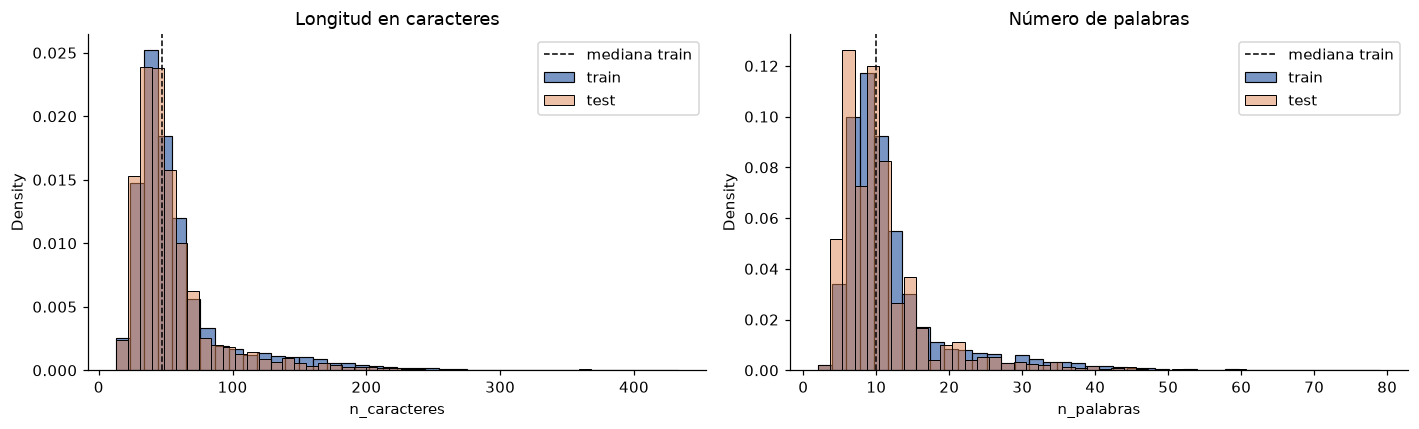

Clases con consultas más cortas (media de palabras):


,n_palabras
category,
card_acceptance,7.5
atm_support,7.7
passcode_forgotten,7.7
get_physical_card,7.7
top_up_limits,7.7


Clases con consultas más largas:


,n_palabras
category,
direct_debit_payment_not_recognised,16.0
failed_transfer,16.0
pending_cash_withdrawal,16.5
transfer_fee_charged,17.4
transfer_not_received_by_recipient,17.5


In [5]:
# Histogramas de densidad de train y test superpuestos, con la mediana de train como referencia
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
for eje, col, titulo in zip(ejes, ["n_caracteres", "n_palabras"],
                            ["Longitud en caracteres", "Número de palabras"]):
    sns.histplot(train_df[col], bins=40, ax=eje, color="#4C72B0", label="train", stat="density")
    sns.histplot(test_df[col], bins=40, ax=eje, color="#DD8452", label="test", stat="density", alpha=.5)
    eje.axvline(train_df[col].median(), ls="--", c="k", lw=1, label="mediana train")
    eje.set_title(titulo); eje.legend()
# Mostrar la figura
plt.tight_layout(); plt.show()

# Longitud media por clase: ¿hay intenciones que se expresan con frases más largas?
largo_clase = train_df.groupby("category")["n_palabras"].mean().sort_values()
print("Clases con consultas más cortas (media de palabras):")
display(largo_clase.head(5).round(1).to_frame())
print("Clases con consultas más largas:")
display(largo_clase.tail(5).round(1).to_frame())

**Lectura de la figura.** Las dos distribuciones son asimétricas a la derecha: la mayoría de las consultas tiene
entre 7 y 13 palabras (primer y tercer cuartil de train) y una cola larga llega a 79 palabras. Train y test se
superponen casi por completo, así que la prueba mide al modelo en el mismo tipo de texto con el que aprende.
Las intenciones sobre transferencias son las más largas (hasta 17.5 palabras de media) porque el cliente cuenta
una historia; las de aceptación de tarjeta o PIN, las más cortas.

### 2.2 Limpieza básica del texto

Se aplica: (1) conversión a minúsculas, (2) eliminación de caracteres especiales (todo lo que
no sea letra, dígito o espacio) y (3) eliminación de *stopwords* del inglés (lista de NLTK).

> **Importante:** esta limpieza se usa **solo para el análisis exploratorio** (frecuencias,
> n-gramas y nube de palabras). El Transformer recibe el **texto original**, porque su
> tokenizador y su preentrenamiento aprovechan la puntuación y, sobre todo, palabras que NLTK
> considera *stopwords* pero que cambian la intención — por ejemplo *not*, *no*, *why*, *how* o
> *up*: «*My card is **not** working*» queda como «card working», y «*How do I top **up** my
> card?*» como «top card». (*can't* también desaparece, pero no por ser stopword: la regla de
> caracteres especiales lo parte en «can» y «t», y esas dos sí lo son.)

In [6]:
# Lista de stopwords del inglés de NLTK; si no hay red, la equivalente de scikit-learn
import nltk
from nltk.corpus import stopwords
try:
    STOPWORDS = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords", quiet=True)
    try:
        STOPWORDS = set(stopwords.words("english"))
    except LookupError:  # sin red o sin certificados: lista equivalente de scikit-learn
        from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as STOPWORDS

def limpiar(texto: str) -> str:
    """Minúsculas → quitar caracteres especiales → quitar stopwords y tokens de 1 carácter."""
    texto = texto.lower()
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    return " ".join(t for t in texto.split() if t not in STOPWORDS and len(t) > 1)

# Aplicar la limpieza a las dos particiones (columna nueva: el texto original se conserva)
for df in (train_df, test_df):
    df["texto_limpio"] = df["text"].apply(limpiar)

# Corpus completo (train + test) para las frecuencias del análisis exploratorio
todas = pd.concat([train_df, test_df], ignore_index=True)
print(f"Stopwords usadas: {len(STOPWORDS)}")
# Palabras con intención que la lista trata como stopwords (y por eso el Transformer recibe el texto original)
print("Palabras con intención incluidas en la lista:", [w for w in ["not", "no", "why", "how", "up", "don't", "didn't"] if w in STOPWORDS])
for ejemplo in ["My card is not working", "How do I top up my card?", "I can't transfer money"]:
    print(f"   {ejemplo!r:32} → {limpiar(ejemplo)!r}")
display(todas[["text", "texto_limpio"]].sample(6, random_state=1))

Stopwords usadas: 198
Palabras con intención incluidas en la lista: ['not', 'no', 'why', 'how', 'up', "don't", "didn't"]
   'My card is not working'         → 'card working'
   'How do I top up my card?'       → 'top card'
   "I can't transfer money"         → 'transfer money'


,text,texto_limpio
4641,A direct debit payment that I didn't authorise shows up in my app.,direct debit payment authorise shows app
8523,My credit card was just denied for top up! Can you tell me why this happened and what's going on?,credit card denied top tell happened going
1595,How old do you have to be?,old
854,"I have a cash withdrawal that says it's pending, why?",cash withdrawal says pending
4226,Will I get a visa or Mastercard?,get visa mastercard
8208,The wrong exchange rate was applied to me while pulling out cash.,wrong exchange rate applied pulling cash


### 2.3 Palabras, bigramas y trigramas más frecuentes

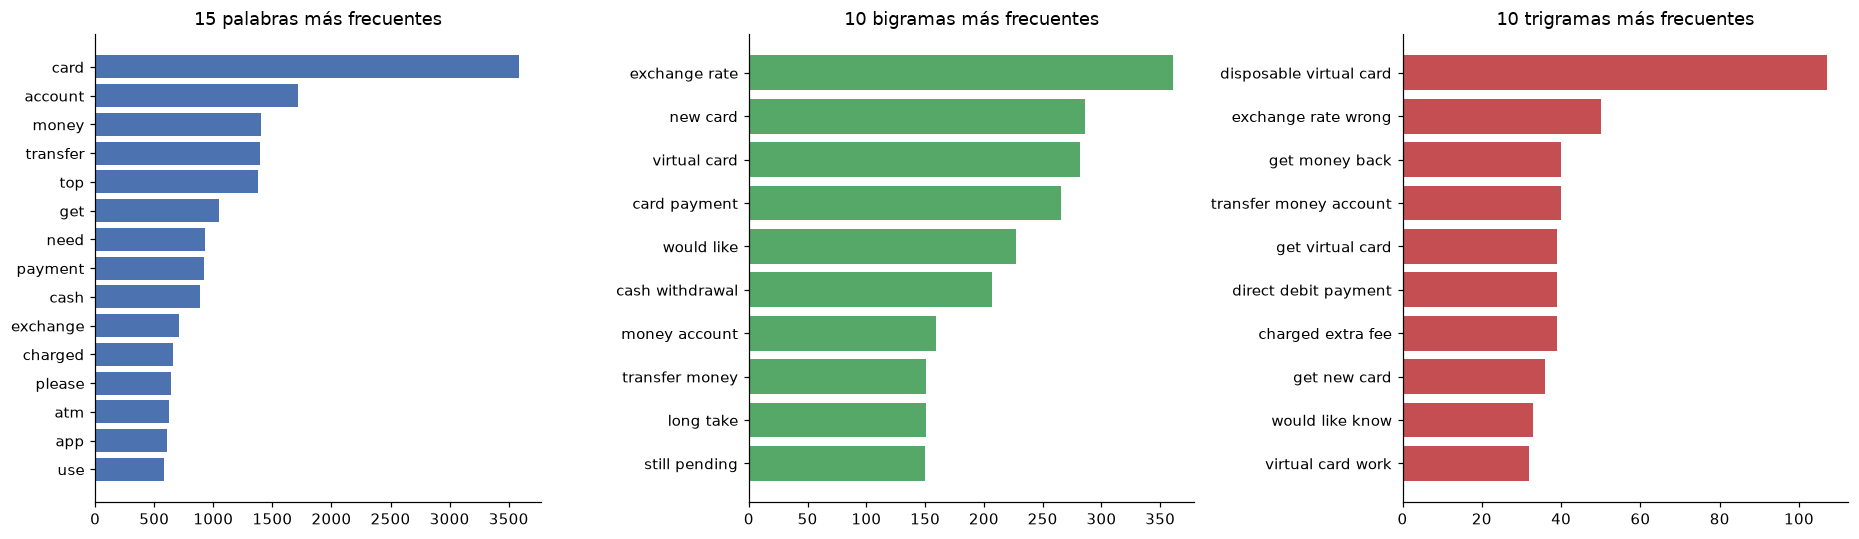

Palabras                    Bigramas                           Trigramas  \
      ngrama frecuencia           ngrama frecuencia                   ngrama   
0       card       3591    exchange rate      361.0  disposable virtual card   
1    account       1716         new card      286.0      exchange rate wrong   
2      money       1407     virtual card      282.0           get money back   
3   transfer       1392     card payment      266.0   transfer money account   
4        top       1381       would like      227.0         get virtual card   
5        get       1045  cash withdrawal      207.0     direct debit payment   
6       need        927    money account      159.0        charged extra fee   
7    payment        921   transfer money      151.0             get new card   
8       cash        884        long take      151.0          would like know   
9   exchange        708    still pending      150.0        virtual card work   
10   charged        660                                                        
11    please        643                                                        
12       atm        624                                                        
13       app        611                                                        
14       use        579                                                        

               
   frecuencia  
0       107.0  
1        50.0  
2        40.0  
3        40.0  
4        39.0  
5        39.0  
6        39.0  
7        36.0  
8        33.0  
9        32.0  
10             
11             
12             
13             
14

In [7]:
# CountVectorizer cuenta n-gramas; el patrón de token acepta también palabras de una letra
from sklearn.feature_extraction.text import CountVectorizer

def top_ngramas(textos, n, k):
    """Devuelve los k n-gramas más frecuentes (sobre el texto ya limpio)."""
    vec = CountVectorizer(ngram_range=(n, n), token_pattern=r"(?u)\b\w+\b")
    X = vec.fit_transform(textos)
    frec = np.asarray(X.sum(axis=0)).ravel()
    orden = frec.argsort()[::-1][:k]
    return pd.DataFrame({"ngrama": vec.get_feature_names_out()[orden], "frecuencia": frec[orden]})

# Frecuencias sobre el texto limpio: 150 palabras (15 para la tabla, 150 para la nube), 10 bigramas y 10 trigramas
corpus_limpio = todas["texto_limpio"]
top_palabras = top_ngramas(corpus_limpio, 1, 150)   # la nube de 2.4 usa exactamente estas frecuencias
top_bigramas = top_ngramas(corpus_limpio, 2, 10)
top_trigramas = top_ngramas(corpus_limpio, 3, 10)

# Tres gráficas de barras horizontales, de mayor a menor frecuencia
fig, ejes = plt.subplots(1, 3, figsize=(17, 5))
for eje, df_, titulo, color in zip(
        ejes, [top_palabras.head(15), top_bigramas, top_trigramas],
        ["15 palabras más frecuentes", "10 bigramas más frecuentes", "10 trigramas más frecuentes"],
        ["#4C72B0", "#55A868", "#C44E52"]):
    eje.barh(df_["ngrama"][::-1], df_["frecuencia"][::-1], color=color)
    eje.set_title(titulo)
plt.tight_layout(); plt.show()

# Las tres listas lado a lado en una sola tabla
display(pd.concat([top_palabras.head(15).reset_index(drop=True),
                   top_bigramas, top_trigramas], axis=1,
                  keys=["Palabras", "Bigramas", "Trigramas"]).fillna(""))

**Lectura de la figura.** Cinco palabras dominan el vocabulario limpio (*card*, *account*, *money*, *transfer*,
*top*) y los bigramas y trigramas más frecuentes son justo las expresiones que comparten varias intenciones
(*exchange rate*, *virtual card*, *new card*, *disposable virtual card*). Es la primera señal de que las
confusiones se darán entre intenciones vecinas, algo que se mide en la sección 3.6.

### 2.4 Nube de palabras

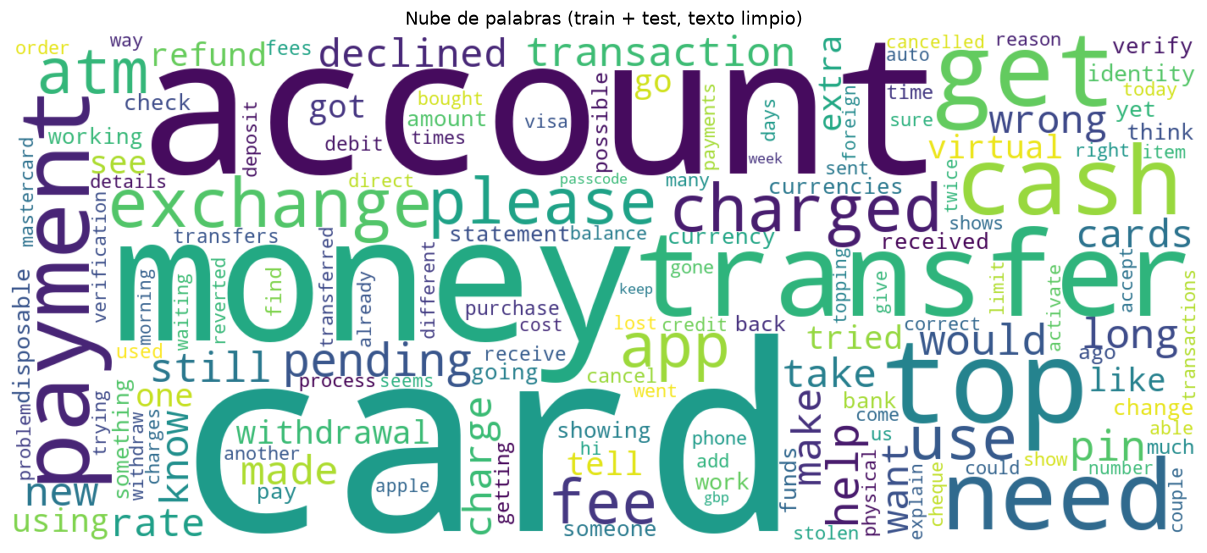

In [8]:
# Nube de palabras: el tamaño de cada palabra es proporcional a su frecuencia en el texto limpio
from wordcloud import WordCloud

# Mismas frecuencias que la tabla de 2.3 (150 palabras), sin fusionar bigramas; semilla fija para la disposición
nube = WordCloud(width=1400, height=600, background_color="white", colormap="viridis", max_words=150,
                 random_state=SEED).generate_from_frequencies(dict(zip(top_palabras.ngrama, top_palabras.frecuencia)))
# Dibujar la nube sin ejes
plt.figure(figsize=(14, 6)); plt.imshow(nube, interpolation="bilinear"); plt.axis("off")
plt.title("Nube de palabras (train + test, texto limpio)"); plt.show()

**Lectura de la figura.** La nube usa exactamente las frecuencias de la tabla anterior (150 palabras), sin fusionar
bigramas: *card* domina con claridad, seguida de *account*, *money*, *transfer* y *top*. Visualmente confirma que el
dataset gira alrededor de pocos objetos —tarjeta, cuenta, dinero, transferencia y recarga— y que las 77 intenciones
se distinguen más por los verbos y los matices (*not working*, *pending*, *declined*) que por los sustantivos.

### 2.5 ¿Está balanceado el conjunto de datos?

,valor
mínimo (train),35
clase mínima,contactless_not_working
máximo (train),187
clase máxima,card_payment_fee_charged
razón máx/mín,5.34
coeficiente de variación,0.254
entropía normalizada,0.992
test: valores distintos,[40]


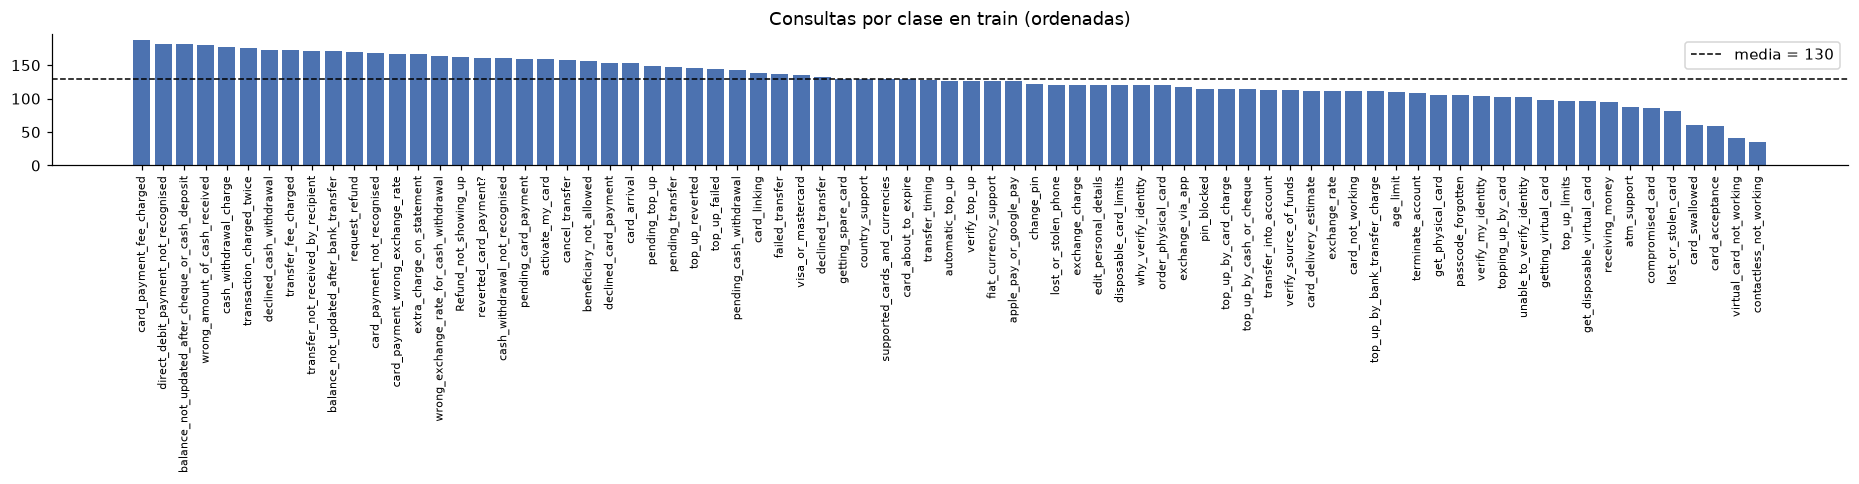

In [9]:
# Número de consultas por clase en cada partición, en el orden oficial de las etiquetas
conteo = pd.DataFrame({
    "train": train_df["category"].value_counts(),
    "test": test_df["category"].value_counts(),
}).reindex(ETIQUETAS)

# Medidas de balance sobre train: extremos, razón máx/mín, coeficiente de variación y entropía
c = conteo["train"]
# Proporción de cada clase (para la entropía normalizada: 1 = perfectamente balanceado)
p = c / c.sum()
balance = {
    "mínimo (train)": int(c.min()), "clase mínima": c.idxmin(),
    "máximo (train)": int(c.max()), "clase máxima": c.idxmax(),
    "razón máx/mín": round(c.max() / c.min(), 2),
    "coeficiente de variación": round(c.std() / c.mean(), 3),
    "entropía normalizada": round(float(-(p * np.log(p)).sum() / np.log(N_CLASES)), 4),
    "test: valores distintos": sorted(conteo["test"].unique().tolist()),
}
# Tabla de medidas de balance
display(pd.Series(balance, name="valor").to_frame())

# Barras de las 77 clases ordenadas de mayor a menor, con la media como línea de referencia
fig, eje = plt.subplots(figsize=(17, 4.5))
orden = c.sort_values(ascending=False)
eje.bar(range(N_CLASES), orden.values, color="#4C72B0")
eje.axhline(c.mean(), c="k", ls="--", lw=1, label=f"media = {c.mean():.0f}")
eje.set_xticks(range(N_CLASES)); eje.set_xticklabels(orden.index, rotation=90, fontsize=7)
eje.set_title("Consultas por clase en train (ordenadas)"); eje.legend()
plt.tight_layout(); plt.show()

**Lectura de la figura.** Las barras bajan de forma gradual, sin saltos: 11 clases tienen menos de 100 ejemplos, 42
entre 100 y 149 y 24 al menos 150 (media 130). El desbalance es moderado y continuo, no hay clases marginales.

### 2.6 Conclusiones del análisis exploratorio

**Longitud.** Las consultas son **cortas y muy asimétricas**: en entrenamiento la mediana es de **10 palabras
(47 caracteres)** y la media de 11.95, pero la cola llega a **79 palabras (433 caracteres)**. La desviación estándar
(7.89 palabras) es casi el 66 % de la media: una minoría de consultas largas, con contexto narrativo, convive con
muchas de 5 a 10 palabras. La prueba tiene la misma forma, con consultas algo más cortas (mediana de 9 palabras),
así que no hay un desplazamiento de distribución preocupante.

**Vocabulario.** Tras la limpieza dominan **card (3 591), account (1 716), money, transfer y top**. Los bigramas y
trigramas más frecuentes (*exchange rate*, *new card*, *virtual card*, *disposable virtual card*, *get money back*)
son expresiones que **varias intenciones comparten**, así que el sustantivo no basta para decidir: lo decide el
resto de la frase (*how many* → límites; *not working* → fallo).

**Limpieza.** La lista de stopwords de NLTK (198 palabras) incluye palabras que llevan la intención: *not*, *no*,
*why*, *how* y *up*. «My card is not working» queda en «card working» y «How do I top up my card?» en «top card»
(la celda de 2.2 lo muestra). *can't* también desaparece, pero no por ser stopword: la regla de caracteres
especiales lo parte en «can» y «t», que sí lo son. Por eso la versión limpia se usa solo para este análisis.

**Balance.** Entrenamiento **moderadamente desbalanceado**: de **35** consultas (`contactless_not_working`) a
**187** (`card_payment_fee_charged`), una razón de **5.3×** y un coeficiente de variación de 0.25; la entropía
normalizada es **0.992** (1 = uniforme). La **prueba está perfectamente balanceada (40 por clase)**, así que accuracy
y F1 macro medirán casi lo mismo.

**Implicaciones para el modelo de clasificación** (lo que este análisis decide antes de entrenar):

1. **Consultas cortas** → la longitud máxima se fija con la distribución de tokens (sección 3.1) sin truncar
   ninguna consulta, y un lote de 32 cabe holgado en memoria.
2. **Vocabulario compartido entre intenciones** → hace falta un modelo contextual, no una bolsa de palabras; y se
   anticipa que transferencias, recargas y tarjetas concentrarán las confusiones (**hipótesis H2**, sección 3.6).
3. **Las stopwords llevan intención** → el Transformer recibe el texto original.
4. **Desbalance moderado en train y prueba balanceada** → la época se elige por **F1 macro**, que pesa igual las 77
   clases, y se comprueba si el tamaño de la clase explica los errores (**hipótesis H1**, sección 3.6).

## 3. Clasificación con DistilRoBERTa

Un Transformer procesa la frase completa con **autoatención**: cada token se representa en función de
todos los demás (Vaswani et al., 2017). Los codificadores preentrenados como BERT (Devlin et al., 2019) y
RoBERTa (Liu et al., 2019) aprenden esas representaciones sobre grandes corpus sin etiquetar y luego se
**afinan** para una tarea concreta.

**DistilRoBERTa** (`distilroberta-base`) es la versión **destilada** de RoBERTa, con la técnica de
DistilBERT (Sanh et al., 2019): 6 capas de Transformer en lugar de 12 y 82 M de parámetros frente a
125 M; según la ficha oficial del modelo en Hugging Face es, en promedio, el doble de rápida que
RoBERTa-base. Se usa *transfer learning*: se parte de los pesos preentrenados en inglés y se añade una
cabeza de clasificación de 77 salidas sobre el token `<s>`; después se afina **todo** el modelo con las
consultas etiquetadas, con la librería `transformers` (Wolf et al., 2020).

### 3.1 Tokenización

In [10]:
from transformers import AutoTokenizer

# Tokenizador BPE de DistilRoBERTa (el mismo vocabulario de 50 265 sub-palabras que RoBERTa)
MODELO_BASE = "distilbert/distilroberta-base"   # alias oficial de "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODELO_BASE)

# Ejemplo: texto → tokens (sub-palabras; «Ġ» marca un espacio antes) → identificadores numéricos
ejemplo = train_df["text"].iloc[0]
enc = tokenizer(ejemplo)
print("Texto   :", ejemplo)
print("Tokens  :", tokenizer.convert_ids_to_tokens(enc["input_ids"]))
print("IDs     :", enc["input_ids"])

# Distribución de la longitud en tokens (incluye <s> y </s>) para fijar max_length
for df in (train_df, test_df):
    df["n_tokens"] = [len(x) for x in tokenizer(df["text"].tolist())["input_ids"]]
q = train_df["n_tokens"].quantile([.5, .95, .99, 1]).astype(int)
print(f"\nTokens por consulta (train) → mediana {q[.5]}, p95 {q[.95]}, p99 {q[.99]}, máximo {q[1.0]}")
# Regla: 64 tokens si ninguna consulta los supera; si alguna los supera, 128 (así nada se trunca)
MAX_LEN = 64 if max(train_df.n_tokens.max(), test_df.n_tokens.max()) <= 64 else 128
print(f"max_length elegido = {MAX_LEN}  (consultas truncadas en test: {(test_df.n_tokens > MAX_LEN).sum()})")

Texto   : I am still waiting on my card?
Tokens  : ['<s>', 'I', 'Ġam', 'Ġstill', 'Ġwaiting', 'Ġon', 'Ġmy', 'Ġcard', '?', '</s>']
IDs     : [0, 100, 524, 202, 2445, 15, 127, 1886, 116, 2]



Tokens por consulta (train) → mediana 13, p95 36, p99 51, máximo 96
max_length elegido = 128  (consultas truncadas en test: 0)


### 3.2 Partición de validación y preparación de los datos

El conjunto de **prueba (3 080) no se toca** hasta la evaluación final. Del entrenamiento se
separa un **10 % estratificado** como validación, que se usa para elegir la mejor época
(*early stopping*).

In [11]:
# Partición de validación y conversión a Dataset de Hugging Face
from sklearn.model_selection import train_test_split
from datasets import Dataset

# 10 % de train como validación, estratificado por clase; el conjunto de prueba no se toca
tr_df, val_df = train_test_split(train_df, test_size=0.10, stratify=train_df["label"], random_state=SEED)
print(f"entrenamiento: {len(tr_df):,} · validación: {len(val_df):,} · prueba: {len(test_df):,}")

# Pasar un DataFrame a Dataset y tokenizarlo por lotes (el relleno se hace después, por lote)
def a_dataset(df):
    ds = Dataset.from_pandas(df[["text", "label"]].reset_index(drop=True))
    return ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LEN), batched=True,
                  remove_columns=["text"])

# Las tres particiones tokenizadas
ds_tr, ds_val, ds_test = a_dataset(tr_df), a_dataset(val_df), a_dataset(test_df)
ds_tr

entrenamiento: 9,002 · validación: 1,001 · prueba: 3,080


Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 9002
})

### 3.3 Fine-tuning

| Hiperparámetro | Valor | Motivo |
|---|---|---|
| Tasa de aprendizaje | 5e-5 con *warmup* del 10 % y decaimiento lineal | valor estándar para afinar modelos BERT |
| Tamaño de lote | 32 | cabe holgado en memoria: las consultas son cortas (mediana de 13 tokens) |
| Épocas | hasta 8, *early stopping* con paciencia 2 | evita sobreajuste: se queda la mejor época en validación |
| Métrica de selección | F1 macro en validación | trata igual a las 77 clases |
| *Weight decay* | 0.01 | regularización |
| Relleno | dinámico por lote | no se desperdicia cómputo en `<pad>` |

In [12]:
# Clases de Hugging Face para el fine-tuning y métricas de scikit-learn
from transformers import (AutoModelForSequenceClassification, TrainingArguments, Trainer,
                          DataCollatorWithPadding, EarlyStoppingCallback)
from sklearn.metrics import accuracy_score, f1_score

# DistilRoBERTa preentrenado + cabeza de clasificación nueva de 77 salidas (se inicializa al azar)
modelo = AutoModelForSequenceClassification.from_pretrained(
    MODELO_BASE, num_labels=N_CLASES,
    id2label=dict(enumerate(ETIQUETAS)), label2id=ID)
print(f"Parámetros entrenables: {sum(p.numel() for p in modelo.parameters() if p.requires_grad)/1e6:.1f} M")

# Métricas que el Trainer calcula en validación al final de cada época
def metricas(pred):
    y_pred = pred.predictions.argmax(-1)
    return {"accuracy": accuracy_score(pred.label_ids, y_pred),
            "f1_macro": f1_score(pred.label_ids, y_pred, average="macro")}

# Warmup del 10 % expresado en pasos (compatible con transformers 4.x y 5.x)
PASOS_WARMUP = int(0.10 * 8 * np.ceil(len(ds_tr) / 32))
# Hiperparámetros del fine-tuning (ver la tabla anterior); se guarda y restaura la mejor época por F1 macro
args = TrainingArguments(
    output_dir=str(RAIZ / "salidas_entrenamiento"), disable_tqdm=True,
    num_train_epochs=8, learning_rate=5e-5, warmup_steps=PASOS_WARMUP, weight_decay=0.01,
    per_device_train_batch_size=32, per_device_eval_batch_size=64,
    eval_strategy="epoch", save_strategy="epoch", logging_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    save_total_limit=2, seed=SEED, report_to="none", dataloader_num_workers=0,
    fp16=(DEVICE == "cuda"),
)
# El Trainer une modelo, datos, relleno dinámico, métricas y early stopping (paciencia de 2 épocas)
trainer = Trainer(model=modelo, args=args, train_dataset=ds_tr, eval_dataset=ds_val,
                  processing_class=tokenizer, data_collator=DataCollatorWithPadding(tokenizer),
                  compute_metrics=metricas, callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])

# Entrenar midiendo el tiempo total
t0 = time.time()
trainer.train()
DURACION_ENTRENAMIENTO = time.time() - t0
print(f"Entrenamiento: {DURACION_ENTRENAMIENTO/60:.1f} min en {DEVICE}")

Parámetros entrenables: 82.2 M


{'loss': '3.162', 'grad_norm': '13.68', 'learning_rate': '4.862e-05', 'epoch': '1'}


{'eval_loss': '1.261', 'eval_accuracy': '0.7812', 'eval_f1_macro': '0.7367', 'eval_runtime': '1.125', 'eval_samples_per_second': '890.1', 'eval_steps_per_second': '14.23', 'epoch': '1'}


{'loss': '0.8302', 'grad_norm': '8.19', 'learning_rate': '4.168e-05', 'epoch': '2'}


{'eval_loss': '0.4696', 'eval_accuracy': '0.8971', 'eval_f1_macro': '0.8946', 'eval_runtime': '1.073', 'eval_samples_per_second': '933.3', 'eval_steps_per_second': '14.92', 'epoch': '2'}


...

{'loss': '0.03964', 'grad_norm': '0.2895', 'learning_rate': '6.967e-06', 'epoch': '7'}


{'eval_loss': '0.3112', 'eval_accuracy': '0.9221', 'eval_f1_macro': '0.9203', 'eval_runtime': '1.257', 'eval_samples_per_second': '796.1', 'eval_steps_per_second': '12.72', 'epoch': '7'}


{'loss': '0.02699', 'grad_norm': '17.32', 'learning_rate': '2.462e-08', 'epoch': '8'}


{'eval_loss': '0.3146', 'eval_accuracy': '0.9241', 'eval_f1_macro': '0.9236', 'eval_runtime': '1.225', 'eval_samples_per_second': '817', 'eval_steps_per_second': '13.06', 'epoch': '8'}


{'train_runtime': '479.1', 'train_samples_per_second': '150.3', 'train_steps_per_second': '4.708', 'train_loss': '0.5943', 'epoch': '8'}
Entrenamiento: 8.0 min en mps


,epoch,train_loss,eval_loss,eval_accuracy,eval_f1_macro
0,1,3.1616,1.2612,0.7812,0.7367
1,2,0.8302,0.4696,0.8971,0.8946
2,3,0.3430,0.3482,0.9081,0.9058
3,4,0.1827,0.3106,0.9141,0.9140
4,5,0.1058,0.3242,0.9201,0.9177
5,6,0.0642,0.2949,0.9321,0.9297
6,7,0.0396,0.3112,0.9221,0.9203
7,8,0.0270,0.3146,0.9241,0.9236


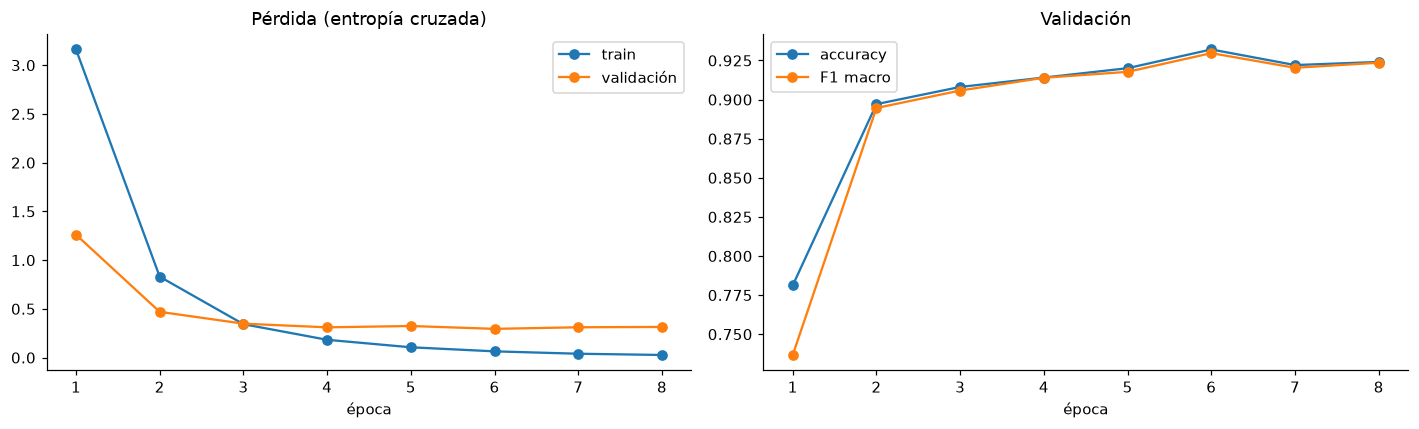

Mejor checkpoint: checkpoint-1692 (F1 macro val = 0.9297)


In [13]:
# Curvas de aprendizaje a partir del historial del Trainer
hist = pd.DataFrame(trainer.state.log_history)
curva = (hist.dropna(subset=["loss"])[["epoch", "loss"]].rename(columns={"loss": "train_loss"})
         .merge(hist.dropna(subset=["eval_loss"])[["epoch", "eval_loss", "eval_accuracy", "eval_f1_macro"]],
                on="epoch"))
curva["epoch"] = curva["epoch"].round().astype(int)
display(curva.round(4))

# Izquierda: pérdida de train y validación. Derecha: accuracy y F1 macro en validación
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
ejes[0].plot(curva.epoch, curva.train_loss, "o-", label="train"); ejes[0].plot(curva.epoch, curva.eval_loss, "o-", label="validación")
ejes[0].set_title("Pérdida (entropía cruzada)"); ejes[0].set_xlabel("época"); ejes[0].legend()
ejes[1].plot(curva.epoch, curva.eval_accuracy, "o-", label="accuracy"); ejes[1].plot(curva.epoch, curva.eval_f1_macro, "o-", label="F1 macro")
ejes[1].set_title("Validación"); ejes[1].set_xlabel("época"); ejes[1].legend()
plt.tight_layout(); plt.show()
# La época que se conserva (y que se evalúa en prueba) es la de mayor F1 macro en validación
print(f"Mejor checkpoint: {Path(trainer.state.best_model_checkpoint).name} (F1 macro val = {trainer.state.best_metric:.4f})")

**Lectura de la figura.** La pérdida de validación baja con fuerza hasta la época 3 y alcanza su mínimo en la
**época 6** (0.295); después sube ligeramente mientras la de entrenamiento sigue cayendo (0.027 en la época 8): a
partir de ahí el modelo empieza a memorizar. El *early stopping* conserva la época 6, la de mayor F1 macro en
validación (0.930).

### 3.4 Evaluación en el conjunto de prueba

In [14]:
# Evaluación final sobre las consultas de prueba, que el modelo no vio en el entrenamiento
from sklearn.metrics import classification_report, confusion_matrix

# Logits → probabilidades con softmax; la clase predicha es la de mayor probabilidad
salida = trainer.predict(ds_test)
logits = torch.tensor(salida.predictions)
probs = torch.softmax(logits, dim=-1).numpy()
y_true = salida.label_ids
y_pred = probs.argmax(-1)
confianza = probs.max(-1)

# Métricas globales
ACCURACY = accuracy_score(y_true, y_pred)
F1_MACRO = f1_score(y_true, y_pred, average="macro")
print(f"Accuracy (test): {ACCURACY:.4f}   ·   F1 macro (test): {F1_MACRO:.4f}")
print(f"Errores: {(y_true != y_pred).sum()} de {len(y_true)}")

# ¿La confianza del modelo distingue aciertos de errores?
acierto = y_true == y_pred
print(f"Confianza media: aciertos {confianza[acierto].mean():.3f} · errores {confianza[~acierto].mean():.3f}")
print(f"Errores cometidos con confianza > 0.90: {(confianza[~acierto] > 0.90).mean():.1%} "
      f"({(confianza[~acierto] > 0.90).sum()} de {(~acierto).sum()})")

# Reporte por clase COMPLETO: precision, recall, F1 y soporte de las 77 intenciones
print()
print(classification_report(y_true, y_pred, target_names=ETIQUETAS, digits=3, zero_division=0))
# La misma información como tabla, para usarla en las secciones siguientes
reporte = pd.DataFrame(classification_report(y_true, y_pred, target_names=ETIQUETAS,
                                             output_dict=True, zero_division=0)).T

Accuracy (test): 0.9325   ·   F1 macro (test): 0.9324
Errores: 208 de 3080
Confianza media: aciertos 0.971 · errores 0.752
Errores cometidos con confianza > 0.90: 34.6% (72 de 208)

                                                  precision    recall  f1-score   support

                                activate_my_card      0.975     0.975     0.975        40
                                       age_limit      1.000     1.000     1.000        40
                         apple_pay_or_google_pay      1.000     1.000     1.000        40
                                     atm_support      1.000     1.000     1.000        40
                                automatic_top_up      1.000     0.975     0.987        40
         balance_not_updated_after_bank_transfer      0.727     0.800     0.762        40
balance_not_updated_after_cheque_or_cash_deposit      1.000     0.950     0.974        40
                         beneficiary_not_allowed      0.949     0.925     0.937        40
       

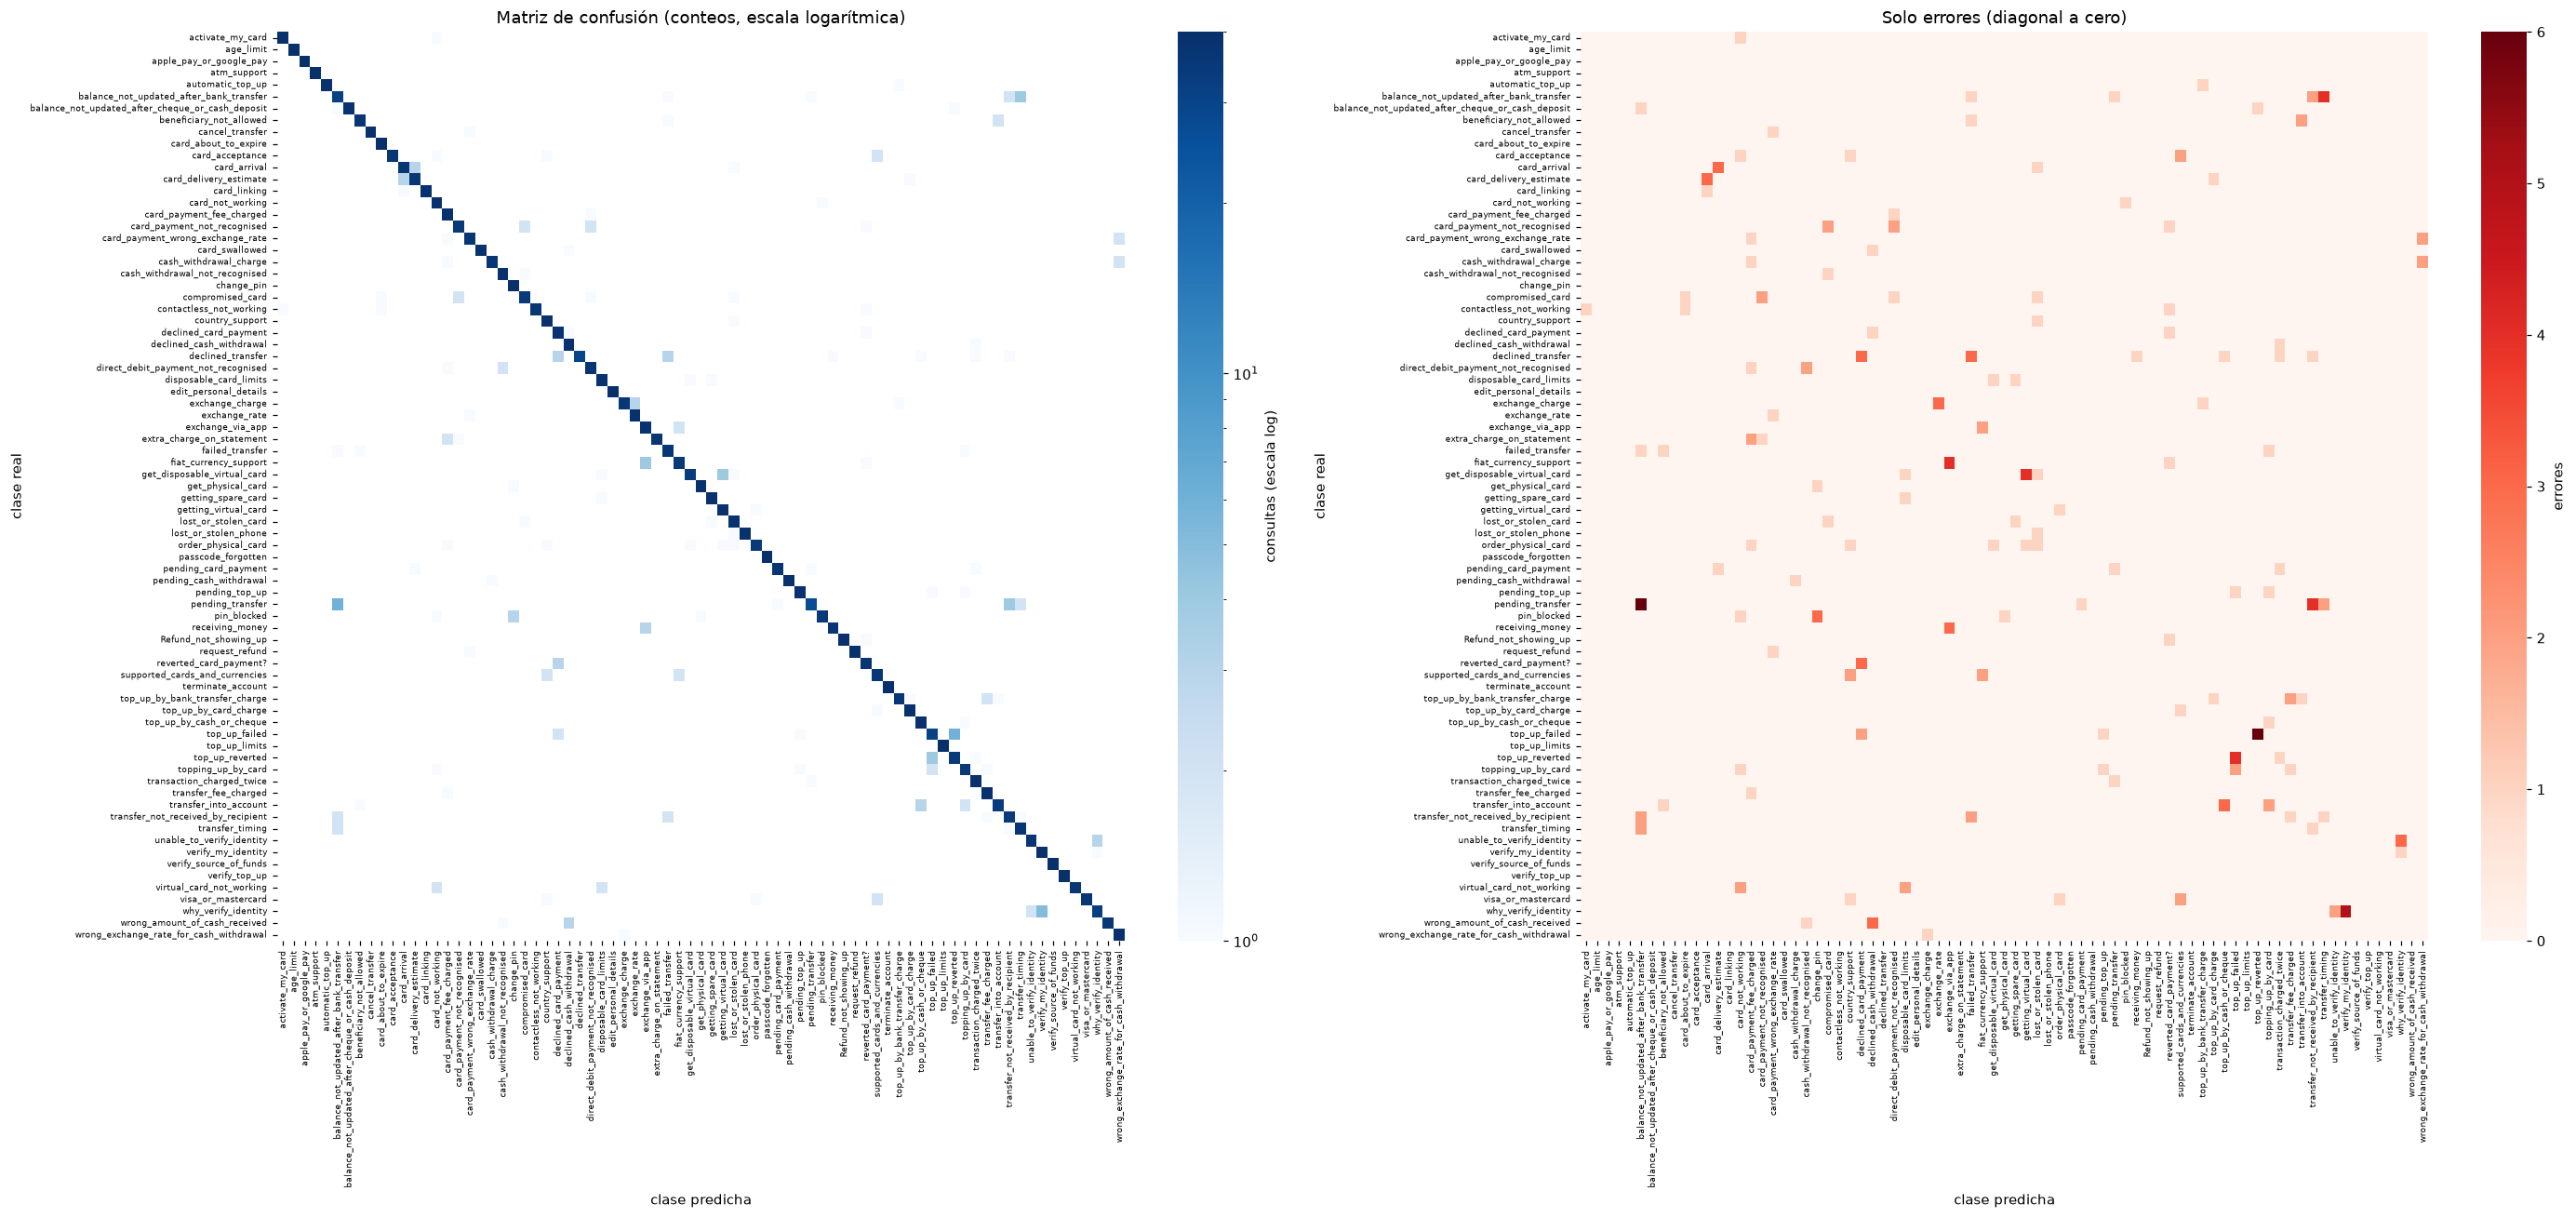

15 pares más confundidos (de 132 pares con al menos un error; empates en orden alfabético):


,real,predicha,errores
0,pending_transfer,balance_not_updated_after_bank_transfer,6
1,top_up_failed,top_up_reverted,6
2,why_verify_identity,verify_my_identity,5
3,balance_not_updated_after_bank_transfer,transfer_timing,4
4,fiat_currency_support,exchange_via_app,4
5,get_disposable_virtual_card,getting_virtual_card,4
6,pending_transfer,transfer_not_received_by_recipient,4
7,top_up_reverted,top_up_failed,4
8,card_arrival,card_delivery_estimate,3
9,card_delivery_estimate,card_arrival,3


In [15]:
# Matriz de confusión 77 × 77 (filas: clase real; columnas: clase predicha)
cm = confusion_matrix(y_true, y_pred, labels=range(N_CLASES))
# Izquierda: todos los conteos en escala logarítmica. Derecha: solo los errores (diagonal a cero)
fig, ejes = plt.subplots(1, 2, figsize=(26, 12))
sns.heatmap(cm, ax=ejes[0], cmap="Blues", norm=__import__("matplotlib.colors", fromlist=["LogNorm"]).LogNorm(vmin=1),
            xticklabels=ETIQUETAS, yticklabels=ETIQUETAS, cbar_kws={"label": "consultas (escala log)"})
ejes[0].set_title("Matriz de confusión (conteos, escala logarítmica)")
fuera = cm.copy(); np.fill_diagonal(fuera, 0)
sns.heatmap(fuera, ax=ejes[1], cmap="Reds", xticklabels=ETIQUETAS, yticklabels=ETIQUETAS,
            cbar_kws={"label": "errores"})
ejes[1].set_title("Solo errores (diagonal a cero)")
# Etiquetas de ejes y tamaño de letra para que quepan los 77 nombres
for e in ejes:
    e.set_xlabel("clase predicha"); e.set_ylabel("clase real")
    e.tick_params(labelsize=6)
plt.tight_layout(); plt.show()

# Pares de clases más confundidos (real → predicha)
pares = (pd.DataFrame([(ETIQUETAS[i], ETIQUETAS[j], fuera[i, j]) for i in range(N_CLASES)
                       for j in range(N_CLASES) if fuera[i, j] > 0], columns=["real", "predicha", "errores"])
         .sort_values(["errores", "real", "predicha"], ascending=[False, True, True], kind="stable")
         .reset_index(drop=True))
print(f"15 pares más confundidos (de {len(pares)} pares con al menos un error; empates en orden alfabético):")
display(pares.head(15))

**Lectura de la figura.** La diagonal concentra casi todo (2 872 aciertos de 3 080). Los 208 errores no se reparten
al azar: el mapa de solo errores muestra celdas aisladas y pequeños grupos junto a la diagonal, que corresponden a
familias de intenciones con nombres y vocabulario parecidos. Los pares más confundidos (tabla) son de
transferencias, recargas, identidad y divisas; ningún par supera los 6 errores en un sentido.

### 3.5 Las siete clases mejor clasificadas y las siete con más errores

Siete clases mejor clasificadas


,precision,recall,f1-score,support,errores
age_limit,1.0,1.0,1.0,40,0
apple_pay_or_google_pay,1.0,1.0,1.0,40,0
atm_support,1.0,1.0,1.0,40,0
edit_personal_details,1.0,1.0,1.0,40,0
passcode_forgotten,1.0,1.0,1.0,40,0
terminate_account,1.0,1.0,1.0,40,0
top_up_limits,1.0,1.0,1.0,40,0


Siete clases con más errores de clasificación


,precision,recall,f1-score,support,errores
pending_transfer,0.900,0.675,0.771,40,13
declined_transfer,1.000,0.750,0.857,40,10
top_up_failed,0.816,0.775,0.795,40,9
balance_not_updated_after_bank_transfer,0.727,0.800,0.762,40,8
why_verify_identity,0.892,0.825,0.857,40,7
transfer_not_received_by_recipient,0.810,0.850,0.829,40,6
transfer_into_account,0.919,0.850,0.883,40,6


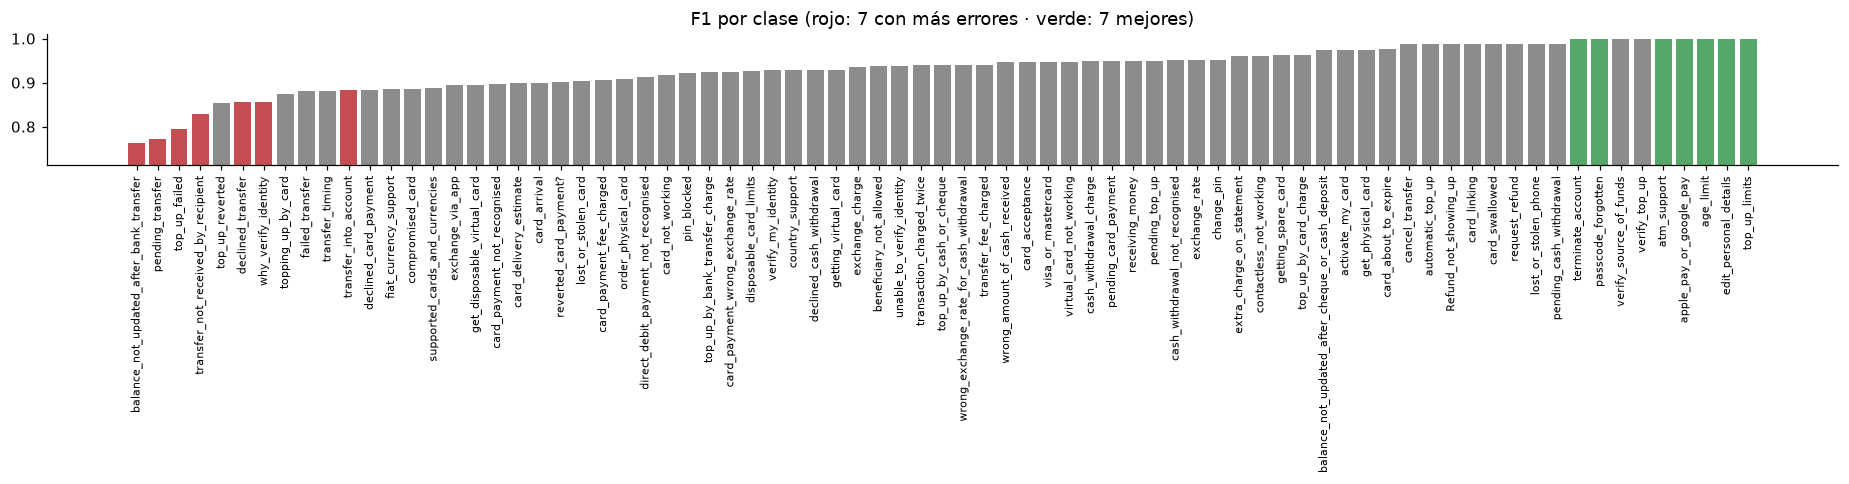

Clases con F1 = 1.000: 9 (se muestran las 7 primeras en el orden oficial)
Clases con 6 errores (el corte de las 7 peores): ['get_disposable_virtual_card', 'transfer_into_account', 'transfer_not_received_by_recipient']


In [16]:
# Tabla por clase con el número de errores (consultas de la clase que no se predijeron bien)
por_clase = reporte.loc[ETIQUETAS, ["precision", "recall", "f1-score", "support"]].copy()
por_clase["support"] = por_clase["support"].astype(int)
por_clase["errores"] = [int(cm[i].sum() - cm[i, i]) for i in range(N_CLASES)]

# Mejores: mayor F1; desempate por menos errores. Peores: más errores; desempate por menor F1.
mejores = por_clase.sort_values(["f1-score", "errores"], ascending=[False, True]).head(7)
peores = por_clase.sort_values(["errores", "f1-score"], ascending=[False, True]).head(7)

# Las dos tablas que pide el enunciado
print("Siete clases mejor clasificadas"); display(mejores.round(3))
print("Siete clases con más errores de clasificación"); display(peores.round(3))

# F1 de las 77 clases ordenado, resaltando las 7 mejores y las 7 con más errores
fig, eje = plt.subplots(figsize=(17, 4.5))
orden = por_clase["f1-score"].sort_values()
colores = ["#C44E52" if n in peores.index else "#55A868" if n in mejores.index else "#8c8c8c" for n in orden.index]
eje.bar(range(N_CLASES), orden.values, color=colores)
eje.set_xticks(range(N_CLASES)); eje.set_xticklabels(orden.index, rotation=90, fontsize=7)
eje.set_ylim(orden.min() - .05, 1.01); eje.set_title("F1 por clase (rojo: 7 con más errores · verde: 7 mejores)")
plt.tight_layout(); plt.show()

# Empates que el orden resuelve (para declararlos en el texto)
print(f"Clases con F1 = 1.000: {int((por_clase['f1-score'] >= 0.9999).sum())} (se muestran las 7 primeras en el orden oficial)")
corte = int(peores["errores"].min())
print(f"Clases con {corte} errores (el corte de las 7 peores): {sorted(por_clase.index[por_clase['errores'] == corte])}")

**Lectura de la figura.** El F1 va de 0.762 a 1.000: 29 clases superan 0.95, 30 están entre 0.90 y 0.95 y 18 por debajo
de 0.90. Hay **empates** que el orden resuelve y conviene declarar: 9 clases tienen F1 = 1.000 (se muestran las 7
primeras en el orden oficial) y tres clases empatan con 6 errores en el corte de las 7 peores
(`get_disposable_virtual_card` queda fuera por tener mayor F1).

### 3.6 Análisis de causas en las clases problemáticas

Para no quedarse en la intuición se miden cuatro cosas: (1) **a qué clases se va** cada clase
problemática cuando falla, (2) **ejemplos reales** de sus errores, (3) la **similitud léxica** entre la
clase real y la predicha —el coseno entre los vectores TF-IDF de todas las consultas de entrenamiento
de cada clase— y (4) qué parte de los errores ocurre **dentro de la misma familia** de intenciones. Si
los errores se concentran en pares con vocabulario muy parecido, la causa es de solapamiento léxico y no
un defecto del entrenamiento. Después, la celda siguiente contrasta las dos hipótesis que dejó el EDA.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

# Similitud léxica entre clases (TF-IDF de las consultas limpias de train, agregadas por clase)
docs_clase = train_df.groupby("label")["texto_limpio"].apply(" ".join).reindex(range(N_CLASES))
sim = cosine_similarity(TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True).fit_transform(docs_clase))
triu = np.triu_indices(N_CLASES, 1)
sim_pares = sim[triu]

# Guardar la predicción y la confianza de cada consulta de prueba y quedarse con los errores
test_df["pred"] = y_pred
test_df["confianza"] = confianza
errores_df = test_df[test_df["label"] != test_df["pred"]].copy()
errores_df["predicha"] = errores_df["pred"].map(lambda i: ETIQUETAS[i])

# Para cada clase problemática: a qué clase se va con más frecuencia y cuán parecidas son léxicamente
filas = []
for clase in peores.index:
    i = ID[clase]
    destinos = errores_df[errores_df.label == i]["predicha"].value_counts()
    dest = destinos.index[0]
    s = sim[i, ID[dest]]
    filas.append({"clase": clase, "errores": int(peores.loc[clase, "errores"]),
                  "principal destino": dest, "errores hacia ese destino": int(destinos.iloc[0]),
                  "similitud TF-IDF": round(float(s), 3),
                  "percentil de similitud": round(float((sim_pares < s).mean() * 100), 1)})
display(pd.DataFrame(filas))

# ¿Los pares más parecidos léxicamente se confunden más?  (correlación de Spearman)
conf_sim = fuera + fuera.T
rho, pval = spearmanr(sim_pares, conf_sim[triu])
print(f"Spearman(similitud léxica, errores entre el par) = {rho:.3f} (p = {pval:.1e}) sobre {len(sim_pares)} pares")

# Familias de intenciones: regla por palabra clave del nombre de la clase (la primera que coincide gana)
REGLAS_FAMILIA = [("identidad", ("identity", "verify")), ("recargas", ("top_up", "topping_up")),
                  ("transferencias", ("transfer", "beneficiary")), ("divisas", ("exchange", "currenc", "fiat")),
                  ("efectivo y cajero", ("cash", "atm")),
                  ("tarjetas", ("card", "pin", "passcode", "contactless", "apple_pay", "visa")),
                  ("cargos y pagos", ("payment", "debit", "charge", "fee", "refund", "statement", "transaction"))]
def familia(clase):
    return next((f for f, claves in REGLAS_FAMILIA if any(k in clase for k in claves)), "cuenta y otros")
FAMILIA = {c: familia(c) for c in ETIQUETAS}
misma = errores_df["category"].map(FAMILIA) == errores_df["predicha"].map(FAMILIA)
print(f"Errores dentro de la misma familia: {misma.mean():.1%} ({misma.sum()} de {len(errores_df)})")
display(pd.Series(FAMILIA).value_counts().rename("clases por familia").to_frame().T)

# Tres errores reales por clase problemática, de mayor a menor confianza
print("\nEjemplos de errores en las clases problemáticas:")
display(errores_df[errores_df["category"].isin(peores.index)]
        .sort_values(["category", "confianza"], ascending=[True, False])
        .groupby("category").head(3)[["text", "category", "predicha", "confianza"]].round(3))

,clase,errores,principal destino,errores hacia ese destino,similitud TF-IDF,percentil de similitud
0,pending_transfer,13,balance_not_updated_after_bank_transfer,6,0.196,99.6
1,declined_transfer,10,declined_card_payment,3,0.189,99.4
2,top_up_failed,9,top_up_reverted,6,0.187,99.4
3,balance_not_updated_after_bank_transfer,8,transfer_timing,4,0.174,99.1
4,why_verify_identity,7,verify_my_identity,5,0.302,99.9
5,transfer_not_received_by_recipient,6,balance_not_updated_after_bank_transfer,2,0.199,99.6
6,transfer_into_account,6,top_up_by_cash_or_cheque,3,0.104,94.8


Spearman(similitud léxica, errores entre el par) = 0.282 (p = 1.1e-54) sobre 2926 pares
Errores dentro de la misma familia: 68.3% (142 de 208)


,tarjetas,transferencias,recargas,cuenta y otros,efectivo y cajero,divisas,identidad,cargos y pagos
clases por familia,28,10,9,7,7,7,5,4



Ejemplos de errores en las clases problemáticas:


,text,category,predicha,confianza
2687,When will my transfer be available in my account.,balance_not_updated_after_bank_transfer,transfer_timing,0.992
2685,How long does it take for an international transfer into my account?,balance_not_updated_after_bank_transfer,transfer_timing,0.983
2701,I transferred some money but it is yet to arrive.,balance_not_updated_after_bank_transfer,transfer_not_received_by_recipient,0.983
1726,"How can I fix my card, it got declined twice.",declined_transfer,transaction_charged_twice,0.979
1752,I can't transfer money from my account.,declined_transfer,failed_transfer,0.977
1736,Why was I unable to do a transfer?,declined_transfer,failed_transfer,0.970
1866,"I would like to know why my payment is still pending, can you help?",pending_transfer,pending_card_payment,0.995
1851,How long can an EU transfer take?,pending_transfer,transfer_timing,0.986
1859,When will the transfer go through?,pending_transfer,transfer_not_received_by_recipient,0.869
2649,Why didn`t my topup go through?,top_up_failed,top_up_reverted,0.956


In [18]:
# ── ¿Explica el EDA los errores? Dos hipótesis que salen del análisis exploratorio ──────────
# H1: el desbalance de clases que midió el EDA (sección 2.5) causa los errores.
# H2: las clases que comparten n-gramas frecuentes (sección 2.3) se confunden entre sí.
# Usa los objetos de esta misma ejecución: conteo (2.5), por_clase y peores (3.5), fuera (3.4) y train_df.
tabla = por_clase.assign(n_train=conteo["train"])

# H1 · Tamaño de la clase en train frente a su F1 en prueba
rho1, p1 = spearmanr(tabla["n_train"], tabla["f1-score"])
print(f"H1 · Spearman(ejemplos de entrenamiento, F1) = {rho1:.3f} (p = {p1:.2f}) sobre {len(tabla)} clases")
print(f"     Las 7 clases con más errores tienen {tabla.loc[peores.index, 'n_train'].mean():.0f} ejemplos de media; "
      f"el promedio general es {tabla['n_train'].mean():.0f}")
print("     Las 7 clases más pequeñas y su F1:")
display(tabla.nsmallest(7, "n_train")[["n_train", "f1-score", "errores"]].round(3))

# H2 · Los 15 bigramas más frecuentes de cada clase (texto limpio de train) y cuántos comparte cada par
docs_bi = train_df.groupby("label")["texto_limpio"].apply(lambda t: "\n".join(t)).reindex(range(N_CLASES)).fillna("")
vec_bi = CountVectorizer(ngram_range=(2, 2), token_pattern=r"(?u)\b\w+\b")
X_bi = vec_bi.fit_transform(docs_bi)
vocab_bi = np.array(vec_bi.get_feature_names_out())
top_bi = {i: set(vocab_bi[np.asarray(X_bi[i].todense()).ravel().argsort()[::-1][:15]]) for i in range(N_CLASES)}

# Jaccard de bigramas frecuentes frente a errores entre cada par (en ambos sentidos)
errores_par = fuera + fuera.T
pares_idx = list(zip(*triu))
jaccard = np.array([len(top_bi[i] & top_bi[j]) / len(top_bi[i] | top_bi[j]) for i, j in pares_idx])
err_par = errores_par[triu]
rho2, p2 = spearmanr(jaccard, err_par)
print(f"\nH2 · Bigramas compartidos (Jaccard): pares que se confunden {jaccard[err_par > 0].mean():.3f} · "
      f"pares que nunca se confunden {jaccard[err_par == 0].mean():.3f} "
      f"({jaccard[err_par > 0].mean() / jaccard[err_par == 0].mean():.0f}× más)")
print(f"     Spearman(bigramas compartidos, errores entre el par) = {rho2:.3f} (p = {p2:.1e})")
# Los pares con más errores y los bigramas frecuentes que comparten (orden estable por nombre en empates)
mas_errores = sorted(pares_idx, key=lambda x: (-errores_par[x], ETIQUETAS[x[0]], ETIQUETAS[x[1]]))[:8]
display(pd.DataFrame([{"par": f"{ETIQUETAS[i]} ↔ {ETIQUETAS[j]}", "errores": int(errores_par[i, j]),
                       "similitud TF-IDF (percentil)": f"{sim[i, j]:.3f} ({(sim_pares < sim[i, j]).mean() * 100:.1f})",
                       "bigramas compartidos": ", ".join(sorted(top_bi[i] & top_bi[j])) or "—"}
                      for i, j in mas_errores]))

H1 · Spearman(ejemplos de entrenamiento, F1) = -0.144 (p = 0.21) sobre 77 clases
     Las 7 clases con más errores tienen 143 ejemplos de media; el promedio general es 130
     Las 7 clases más pequeñas y su F1:


,n_train,f1-score,errores
contactless_not_working,35,0.961,3
virtual_card_not_working,41,0.947,4
card_acceptance,59,0.947,4
card_swallowed,61,0.987,1
lost_or_stolen_card,82,0.905,2
compromised_card,86,0.886,5
atm_support,87,1.000,0



H2 · Bigramas compartidos (Jaccard): pares que se confunden 0.042 · pares que nunca se confunden 0.005 (9× más)
     Spearman(bigramas compartidos, errores entre el par) = 0.306 (p = 2.5e-64)


,par,errores,similitud TF-IDF (percentil),bigramas compartidos
0,top_up_failed ↔ top_up_reverted,10,0.187 (99.4),—
1,balance_not_updated_after_bank_transfer ↔ pending_transfer,7,0.196 (99.6),"days ago, transfers take"
2,balance_not_updated_after_bank_transfer ↔ transfer_timing,6,0.174 (99.1),—
3,card_arrival ↔ card_delivery_estimate,6,0.183 (99.3),"card delivered, new card"
4,exchange_via_app ↔ fiat_currency_support,6,0.160 (98.5),—
5,verify_my_identity ↔ why_verify_identity,6,0.302 (99.9),"identity check, identity need, identity verification, need verify, verify identity, verifying identity"
6,unable_to_verify_identity ↔ why_verify_identity,5,0.174 (99.0),"identity verification, identity verified, verify identity, verifying identity"
7,balance_not_updated_after_bank_transfer ↔ transfer_not_received_by_recipient,4,0.199 (99.6),"days ago, transferred money"


**¿Lo anticipaba el EDA? Las dos hipótesis, medidas en la celda anterior.**

- **H1 — el desbalance causa los errores: no hay evidencia a favor.** La correlación entre los ejemplos de
  entrenamiento de una clase y su F1 es **ρ = −0.14 (p = 0.21)**, no significativa. Las siete clases con más errores
  tienen de media **143 ejemplos**, *más* que el promedio (130), y las siete más pequeñas —como
  `contactless_not_working`, con 35— logran un F1 entre **0.886 y 1.0**. Un resultado no significativo no prueba que el
  desbalance no influya, pero indica que no es el factor principal.
- **H2 — el solapamiento de n-gramas se asocia a los errores: se confirma.** Los pares que se confunden comparten
  **9 veces más bigramas frecuentes** que los que nunca se confunden (Jaccard 0.042 frente a 0.005; ρ = 0.31,
  p ≈ 10⁻⁶⁴). `verify_my_identity` ↔ `why_verify_identity` comparten *verify identity*, *identity check* y *need
  verify*; `card_arrival` ↔ `card_delivery_estimate`, *new card* y *card delivered*. Es una asociación, no una prueba
  causal, pero coincide con lo que anticipó el EDA.

**Las clases problemáticas fallan hacia sus vecinas, no al azar.** Los destinos principales de las siete peores tienen
una similitud TF-IDF con su clase real en el **percentil 94.8–99.9** de los 2 926 pares, y la correlación general entre
similitud y errores es **ρ = 0.28**. Además, el **68.3 % de los errores (142 de 208) ocurre dentro de la misma familia**
de intenciones (regla por palabra clave del nombre, documentada en la celda).

Tres causas concretas, con errores reales de la salida anterior:

1. **Intenciones que difieren en un matiz temporal o de estado.** `pending_transfer` (13 errores, la peor) se va sobre
   todo a `balance_not_updated_after_bank_transfer` (6) y a `transfer_not_received_by_recipient` (4): «When will the
   transfer go through?» se predijo como no recibida. Y `balance_not_updated_after_bank_transfer` se va a
   `transfer_timing` con «When will my transfer be available in my account.». Pendiente, sin llegar y sin reflejarse en
   el saldo son la misma situación contada desde ángulos distintos.
2. **Pares casi sinónimos.** `why_verify_identity` ↔ `verify_my_identity` tiene la similitud más alta (0.30,
   percentil 99.9) y comparte seis bigramas frecuentes.
3. **Etiquetas dudosas.** «How do I top up my card?» está etiquetada como `transfer_into_account` y «How long can an EU
   transfer take?» como `pending_transfer`, cuando `topping_up_by_card` y `transfer_timing` (lo que predijo el modelo)
   son al menos igual de razonables. El ruido de anotación de BANKING77 está documentado (Ying y Thomas, 2022).

**`top_up_failed` ↔ `top_up_reverted`, el par con más errores (10), es un caso aparte:** comparten vocabulario
(similitud TF-IDF en el percentil 99.4) pero **no bigramas frecuentes**. La diferencia está en el verbo —*didn't go
through* / *not work* frente a *reverted*— y en la práctica el cliente describe lo mismo, así que el modelo no tiene una
pista léxica estable. `declined_transfer` es distinto otra vez: **precision 1.0 y recall 0.75**; sus 10 errores se
reparten entre `failed_transfer` (3), `declined_card_payment` (3) y otras cuatro clases, porque *declined* y *can't*
aparecen en varias intenciones de rechazo.

### 3.7 Conclusiones del uso del Transformer

- **El transfer learning funciona muy bien con poco dato.** Con unos 117 ejemplos por clase y **8 minutos** de
  entrenamiento en un portátil (Apple Silicon, MPS), DistilRoBERTa alcanza **93.25 % de accuracy y 0.932 de F1 macro**
  en las 3 080 consultas de prueba, en línea con lo publicado para BANKING77 (≈ 93 % con BERT-base, de 12 capas,
  Casanueva et al., 2020) con la mitad de capas.
- **El entrenamiento es sano y reproducible.** La mejor época es la 6 (F1 macro de validación 0.930) y la métrica en
  prueba (0.932) coincide con la de validación: la validación era representativa. Al repetir la corrida completa se
  obtienen exactamente las mismas 3 080 predicciones.
- **El desempeño es desigual entre clases.** Nueve clases tienen F1 = 1.0 y cuatro quedan por debajo de 0.85, con el
  mínimo en `balance_not_updated_after_bank_transfer` (0.762). Las siete peores concentran **59 de los 208 errores
  (28 %)** siendo el 9 % de las clases. Las mejores tienen vocabulario exclusivo (*age*, *Apple Pay*, *ATM*,
  *terminate*, *passcode*); las peores lo comparten con sus vecinas (H2).
- **La confianza informa, pero no basta.** La celda de 3.4 lo mide: confianza media de **0.971** en los aciertos y
  **0.752** en los errores, pero **el 34.6 % de los errores (72 de 208) se comete con confianza superior a 0.90**. Un
  umbral de derivación a una persona atraparía parte de los errores, no todos.
- **Qué mejoraría el resultado:** ver la sección 3.8, donde cada mejora se deriva de un hallazgo medido.

In [19]:
# Guardar el modelo afinado (lo usa la aplicación web para clasificar en vivo)
trainer.save_model(str(MODELO)); tokenizer.save_pretrained(str(MODELO))
print("Modelo guardado en", MODELO.relative_to(RAIZ), "·", sorted(p.name for p in MODELO.iterdir()))

Modelo guardado en modelo · ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


### 3.8 Mejoras técnicas propuestas: del diagnóstico al ajuste

Cada mejora sale de un hallazgo medido en este notebook, no de una lista genérica:

| Hallazgo (sección) | Ajuste propuesto | Por qué | Referencia |
|---|---|---|---|
| El desbalance de train (5.3×) **no** muestra relación con el F1: ρ = −0.14, p = 0.21 (3.6, H1) | **No** priorizar *class weights*; si se prueban, pérdida ponderada por el número efectivo de muestras | Reponderar clases pequeñas que ya aciertan (F1 ≥ 0.886) movería la frontera a costa de las grandes sin atacar la causa | Cui et al. (2019) |
| Los pares confusos comparten 9× más bigramas frecuentes (3.6, H2) | ***Data augmentation* textual dirigida** a esos pares: paráfrasis que marquen el matiz (pendiente / no recibido / saldo sin actualizar) con *back-translation* y operaciones EDA | Aumentar datos al azar no ayuda; ampliar la frontera entre clases vecinas sí | Wei y Zou (2019); Sennrich et al. (2016) |
| Varias etiquetas del dataset son dudosas (3.6 y revisión manual de 4.7) | **Detectar etiquetas ruidosas** con *confident learning* y corregirlas antes de reentrenar | Parte del techo del modelo es ruido de anotación, no capacidad | Northcutt et al. (2021); Ying y Thomas (2022) |
| El 34.6 % de los errores se comete con confianza > 0.90 (3.4) | **Calibrar las probabilidades** con *temperature scaling* y derivar a una persona las consultas bajo un umbral | Sin calibrar, la confianza no sirve para abstenerse | Guo et al. (2017) |
| Las stopwords llevan la intención (2.2) | Mantener el **texto original** como entrada del Transformer (ya aplicado) | RoBERTa se preentrenó con texto sin limpiar; quitar *not* o *why* cambia la intención | Liu et al. (2019) |
| `top_up_failed` ↔ `top_up_reverted` se confunden sin compartir bigramas frecuentes (3.6) | Modelo de más capacidad (RoBERTa-base) o **ensamble** | Más capas de atención separan mejor matices que no dependen de expresiones compartidas | Liu et al. (2019); Sanh et al. (2019) |

**El vínculo EDA → ajustes, en una línea:** el análisis exploratorio señaló dos sospechosos —el desbalance y el
vocabulario compartido—; la evaluación no encontró relación con el primero y confirmó la asociación con el segundo,
así que la inversión va a los datos de los pares confusos y a la calidad de las etiquetas, no a reponderar clases.

## 4. Explicación de errores con Falcon-7b-instruct

### 4.1 Carga del modelo

`tiiuae/falcon-7b-instruct` es la versión ajustada con instrucciones de Falcon-7B (Almazrouei et al.,
2023): 7 mil millones de parámetros, ≈ 14 GB en `float16`. Antes de cargarlo se libera el clasificador.
En Colab se cuantiza a 4 bits NF4 (Dettmers et al., 2023) para que entre en la T4; en Apple Silicon cabe
en `float16` en la memoria unificada. La celda imprime la memoria que ocupa realmente.

In [20]:
from transformers import AutoModelForCausalLM

# Liberar memoria del clasificador antes de cargar el LLM
del trainer, modelo
gc.collect()
if DEVICE == "cuda": torch.cuda.empty_cache()
if DEVICE == "mps": torch.mps.empty_cache()

# Carga de Falcon-7b-instruct según el acelerador disponible
LLM_ID = "tiiuae/falcon-7b-instruct"
t0 = time.time()
tok_llm = AutoTokenizer.from_pretrained(LLM_ID)
# Colab (GPU T4): cuantización NF4 de 4 bits con bitsandbytes
if DEVICE == "cuda":
    from transformers import BitsAndBytesConfig
    llm = AutoModelForCausalLM.from_pretrained(LLM_ID, device_map="auto", quantization_config=BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16))
elif DEVICE == "mps":
    # Cargar directo en MPS con device_map aborta (SIGBUS) en macOS; en CPU y luego .to("mps") funciona
    llm = AutoModelForCausalLM.from_pretrained(LLM_ID, dtype=torch.float16).to("mps")
else:
    llm = AutoModelForCausalLM.from_pretrained(LLM_ID, dtype=torch.bfloat16)
# Modo inferencia: sin dropout
llm.eval()
print(f"{LLM_ID} cargado en {time.time()-t0:.0f} s · {llm.num_parameters()/1e9:.2f} B parámetros · {llm.dtype}")

# Memoria ocupada por el modelo (verificación que pide el enunciado, en cualquier acelerador)
if DEVICE == "cuda":
    print(f"VRAM ocupada: {torch.cuda.memory_allocated() / 1e9:.2f} GB de {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    import subprocess; print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)
elif DEVICE == "mps":
    print(f"Memoria MPS ocupada: {torch.mps.current_allocated_memory() / 1e9:.2f} GB")

tiiuae/falcon-7b-instruct cargado en 37 s · 6.92 B parámetros · torch.float16
Memoria MPS ocupada: 14.06 GB


### 4.2 Diseño del prompt y sus tres variantes de estructura

La base del diseño son cinco piezas, cada una pensada contra un tipo de alucinación:

| Pieza | Para qué |
|---|---|
| **Rol** («analista de soporte bancario que audita un clasificador») | fija el dominio y el tono |
| **Tarea explícita**: explicar por qué el clasificador eligió la intención *predicha* | evita que el modelo responda al cliente |
| **Restricciones**: máximo dos oraciones, referirse solo a palabras de la consulta, no inventar | ataca la alucinación y la longitud |
| **Datos**: consulta, intención predicha y etiqueta del dataset, con nombres legibles | da al modelo todo lo que necesita y nada más |
| **Ancla de salida** `Explanation:` | el modelo empieza a escribir la explicación directamente |

Para **calibrar la claridad y la estructura** (el tercer eje que pide el enunciado) se comparan tres variantes
que solo difieren en la estructura; todas se envían en inglés, el idioma de las consultas y de las
instrucciones con que se ajustó Falcon (en español se incluye la traducción):

| Variante | Qué cambia | Hipótesis |
|---|---|---|
| **P1 · premisa de error** | afirma que la predicción es INCORRECTA y pide explicar por qué se eligió | el encuadre puede empujar al modelo a racionalizar |
| **P2 · neutral con citas** | no afirma quién tiene razón y obliga a citar entre comillas simples las palabras de la consulta | citas exactas → explicaciones verificables |
| **P3 · P2 + dos ejemplos** (*few-shot*, Brown et al., 2020) | añade dos ejemplos resueltos con consultas del conjunto de **entrenamiento** | los ejemplos fijan el formato y el tipo de razonamiento |

**P1 en inglés (tal como se envía) y en español:**

| Inglés | Español |
|---|---|
| You are a banking customer-support analyst who audits an automatic intent classifier. | Eres un analista de atención a clientes bancarios que audita un clasificador automático de intenciones. |
| The classifier read the customer query below and predicted an intent that is WRONG. | El clasificador leyó la consulta del cliente de abajo y predijo una intención que es INCORRECTA. |
| In at most two short sentences, explain why the classifier probably chose the predicted intent instead of the correct one. | En máximo dos oraciones cortas, explica por qué el clasificador probablemente eligió la intención predicha en lugar de la correcta. |
| Refer only to words that appear in the query. Do not invent facts, do not give advice to the customer. | Refiérete solo a palabras que aparecen en la consulta. No inventes hechos y no des consejos al cliente. |
| Customer query: "{texto}" · Predicted intent: {pred} · Correct intent: {real} · Explanation: | Consulta del cliente: «{texto}» · Intención predicha: {pred} · Intención correcta: {real} · Explicación: |

**P2 en inglés y en español** (lo que cambia respecto de P1):

| Inglés | Español |
|---|---|
| The classifier read the customer query below and predicted an intent that differs from the label in the dataset. | El clasificador leyó la consulta del cliente de abajo y predijo una intención distinta de la etiqueta del dataset. |
| In at most two short sentences, explain which words of the query led the classifier to the predicted intent, quoting those words between single quotes exactly as they appear in the query. | En máximo dos oraciones cortas, explica qué palabras de la consulta llevaron al clasificador a la intención predicha, citándolas entre comillas simples tal como aparecen en la consulta. |
| Dataset label: {real} | Etiqueta del dataset: {real} |

**P3** es P2 precedido de dos ejemplos resueltos (en la celda siguiente, con su traducción en los comentarios).

In [21]:
# Nombre de intención legible para el LLM: card_arrival → «card arrival»
def legible(etiqueta: str) -> str:
    return etiqueta.replace("_", " ").replace("?", "").lower()

CABECERA = "You are a banking customer-support analyst who audits an automatic intent classifier.\n"
# P1 · premisa de error. Español: «El clasificador leyó la consulta… y predijo una intención que es INCORRECTA.
#   En máximo dos oraciones cortas, explica por qué… Refiérete solo a palabras de la consulta. No inventes hechos…»
P1 = (CABECERA +
      "The classifier read the customer query below and predicted an intent that is WRONG.\n"
      "In at most two short sentences, explain why the classifier probably chose the predicted "
      "intent instead of the correct one. Refer only to words that appear in the query. "
      "Do not invent facts, do not give advice to the customer.\n\n"
      'Customer query: "{texto}"\nPredicted intent: {pred}\nCorrect intent: {real}\n\nExplanation:')
# P2 · neutral con citas. Español: «…predijo una intención distinta de la etiqueta del dataset. En máximo dos
#   oraciones cortas, explica qué palabras de la consulta llevaron a la intención predicha, citándolas entre
#   comillas simples tal como aparecen. No inventes hechos…» · «Etiqueta del dataset: {real}»
INSTRUCCION_P2 = (
    "The classifier read the customer query below and predicted an intent that differs from the label in the dataset.\n"
    "In at most two short sentences, explain which words of the query led the classifier to the predicted intent, "
    "quoting those words between single quotes exactly as they appear in the query. "
    "Do not invent facts, do not give advice to the customer.\n\n")
BLOQUE = 'Customer query: "{texto}"\nPredicted intent: {pred}\nDataset label: {real}\n\nExplanation:'
P2 = CABECERA + INSTRUCCION_P2 + BLOQUE
# P3 · P2 + dos ejemplos resueltos con consultas reales del conjunto de ENTRENAMIENTO (no de prueba).
# Traducción de los ejemplos: 1) «Creo que mi recarga fue revertida» → la consulta dice 'top up' y 'reverted';
#   una recarga revertida se parece a una fallida… 2) «¿Cuánto hay que esperar mi tarjeta?» → 'wait' y 'my card'
#   aparecen en mensajes de tarjetas que no han llegado…
EJEMPLOS = (
    'Customer query: "I think my top up has been reverted"\nPredicted intent: top up failed\n'
    "Dataset label: top up reverted\n\nExplanation: The query mentions 'top up' and a reverted top-up looks "
    "like a failed one, which pushes toward top up failed. The word 'reverted' is what points to the label.\n\n"
    'Customer query: "How long is the wait for my card?"\nPredicted intent: card arrival\n'
    "Dataset label: card delivery estimate\n\nExplanation: The words 'wait' and 'my card' are typical of "
    "messages about cards that have not arrived. 'How long' asks for a delivery time, which fits the label better.\n\n")
P3 = CABECERA + INSTRUCCION_P2 + EJEMPLOS + BLOQUE
PROMPTS = {"P1": P1, "P2": P2, "P3": P3}

# Rellenar una plantilla con una consulta y sus dos intenciones
def construir_prompt(texto, pred, real, variante="P1"):
    return PROMPTS[variante].format(texto=texto.strip(), pred=legible(pred), real=legible(real))

# Contar oraciones: se corta después de «.», «!» o «?» seguidos de espacio
def contar_oraciones(texto):
    return len([s for s in re.split(r"(?<=[.!?])\s+", texto.strip()) if s])

@torch.no_grad()
def generar(prompt, max_new_tokens=60, temperature=None, top_p=None):
    """Genera con Falcon. temperature=None → decodificación codiciosa (determinista)."""
    torch.manual_seed(SEED)
    entrada = tok_llm(prompt, return_tensors="pt").to(llm.device)
    muestreo = temperature is not None
    t0 = time.time()
    out = llm.generate(**entrada, max_new_tokens=max_new_tokens, do_sample=muestreo,
                       temperature=temperature if muestreo else None, top_p=top_p if muestreo else None,
                       repetition_penalty=1.15, pad_token_id=tok_llm.eos_token_id,
                       eos_token_id=tok_llm.eos_token_id, stop_strings=["\n\n", "Customer query:"],
                       tokenizer=tok_llm)
    nuevos = out[0, entrada["input_ids"].shape[1]:]
    return tok_llm.decode(nuevos, skip_special_tokens=True).strip(), len(nuevos), time.time() - t0

# Métricas automáticas de cada respuesta (se definen ANTES de ver resultados)
CITA = re.compile(r"(?:(?<=\s)|^)['\"‘“]([^'\"‘’“”]{2,60}?)['\"’”](?=[\s.,;:!?)]|$)")
def medir(salida, n_tok, max_new, texto, pred, real):
    """formato_ok: 1-2 oraciones completas y sin tocar el tope · citas verificables/falsas frente a la consulta."""
    completa = salida.rstrip().endswith((".", "!", "?")) and n_tok < max_new
    citas = [c.strip().lower() for c in CITA.findall(salida)]
    etiquetas = {legible(pred), legible(real)}
    citas = [c for c in citas if c not in etiquetas]          # citar el nombre de la intención no es evidencia
    falsas = [c for c in citas if c not in texto.lower()]
    return {"n_oraciones": contar_oraciones(salida), "completa": completa,
            "formato_ok": completa and 1 <= contar_oraciones(salida) <= 2,
            "citas": len(citas), "cita_falsa": bool(falsas),
            "cita_verificable": bool(citas) and not falsas, "citas_falsas": ", ".join(falsas)}

print(construir_prompt("How do I top up my card?", "topping_up_by_card", "transfer_into_account", "P2"))

You are a banking customer-support analyst who audits an automatic intent classifier.
The classifier read the customer query below and predicted an intent that differs from the label in the dataset.
In at most two short sentences, explain which words of the query led the classifier to the predicted intent, quoting those words between single quotes exactly as they appear in the query. Do not invent facts, do not give advice to the customer.

Customer query: "How do I top up my card?"
Predicted intent: topping up by card
Dataset label: transfer into account

Explanation:


### 4.3 Selección de las 20 consultas mal clasificadas

Criterio reproducible: de todos los errores en prueba se toman los **20 con mayor confianza en la clase
equivocada**, con un máximo de **2 por clase real** para que haya variedad. No es una muestra aleatoria:
son los errores que el modelo comete *con seguridad*, justo los que más conviene entender. Las primeras 8
se usan para calibrar.

In [22]:
# Los 20 errores de mayor confianza, con máximo 2 por clase real para tener variedad
seleccion = (errores_df.sort_values("confianza", ascending=False)
             .groupby("category").head(2).head(20).reset_index().rename(columns={"index": "idx_test"}))
# Numeración 1…20 e identificador estable de la consulta (el mismo que usan la base de datos y la web)
seleccion["orden"] = range(1, len(seleccion) + 1)
seleccion["consulta_id"] = 100000 + seleccion["idx_test"]
# ¿Cuántas de las 20 pertenecen a las 7 clases con más errores?
print(f"De las 20, {seleccion['category'].isin(peores.index).sum()} tienen su clase real entre las 7 con más errores")
display(seleccion[["orden", "consulta_id", "text", "category", "predicha", "confianza"]].round(3))

De las 20, 4 tienen su clase real entre las 7 con más errores


,orden,consulta_id,text,category,predicha,confianza
0,1,101866,"I would like to know why my payment is still pending, can you help?",pending_transfer,pending_card_payment,0.995
1,2,101626,"I was double charged, and the second charge is showing as ""pending"". How long will it be before I get my money back ...",pending_card_payment,transaction_charged_twice,0.994
2,3,102763,Where do I find the exchange rate?,exchange_charge,exchange_rate,0.993
3,4,102637,how many transactions can i make with a disposable card,get_disposable_virtual_card,disposable_card_limits,0.993
4,5,100264,Am I able to exchange currencies?,fiat_currency_support,exchange_via_app,0.992
5,6,100434,Can I change my currency from USD to EUR?,exchange_via_app,fiat_currency_support,0.992
6,7,102544,My card is just not working at this time.,virtual_card_not_working,card_not_working,0.992
7,8,102687,When will my transfer be available in my account.,balance_not_updated_after_bank_transfer,transfer_timing,0.992
8,9,102761,whats your exchange rate,exchange_charge,exchange_rate,0.991
9,10,100618,What are the fees for top-ups?,top_up_by_bank_transfer_charge,top_up_by_card_charge,0.991


### 4.4 Calibración de la decodificación: temperatura y longitud

Se comparan cinco configuraciones con la estructura base (P1) sobre las mismas **8 consultas**. El diseño
**separa los dos factores**: A, B y C cambian solo la temperatura con la misma longitud; B frente a E y C
frente a D cambian solo la longitud con la misma temperatura.

| Config. | Decodificación | `max_new_tokens` |
|---|---|---|
| **A** | codiciosa (`do_sample=False`, equivale a temperatura → 0) | 60 |
| **B** | muestreo, `temperature=0.3`, `top_p=0.9` | 60 |
| **C** | muestreo, `temperature=1.0`, `top_p=0.95` | 60 |
| **D** | muestreo, `temperature=1.0`, `top_p=0.95` | 150 |
| **E** | muestreo, `temperature=0.3`, `top_p=0.9` | 150 |

La temperatura reparte más o menos la probabilidad entre palabras poco probables y `top_p` corta la cola
(muestreo *nucleus*, Holtzman et al., 2020). En todas: `repetition_penalty=1.15` y parada en línea en
blanco. El enunciado habla de `max_length`; en `transformers` ese parámetro cuenta también los tokens del
prompt, así que el control correcto de la longitud de la **respuesta** es `max_new_tokens`.

**Métricas** (definidas en 4.2 antes de ver resultados): *formato correcto* = 1–2 oraciones completas que no
tocan el tope de tokens; *cita falsa* = la respuesta pone entre comillas palabras que no están en la
consulta; *cita verificable* = cita al menos una palabra y todas existen en la consulta.

**Regla de elección fijada de antemano:** gana la configuración con más respuestas en formato correcto;
desempata la que tenga menos citas falsas; luego la menor temperatura; luego la menor longitud.

In [23]:
# Las cinco configuraciones de generación (A-C: efecto de la temperatura; B-E y C-D: efecto de la longitud)
CONFIGS = {
    "A": dict(max_new_tokens=60, temperature=None, top_p=None),
    "B": dict(max_new_tokens=60, temperature=0.3, top_p=0.9),
    "C": dict(max_new_tokens=60, temperature=1.0, top_p=0.95),
    "D": dict(max_new_tokens=150, temperature=1.0, top_p=0.95),
    "E": dict(max_new_tokens=150, temperature=0.3, top_p=0.9),
}
TEMP = {k: (v["temperature"] or 0.0) for k, v in CONFIGS.items()}
calib = seleccion.head(8)

# Generar con cada configuración sobre las mismas 8 consultas y medir cada salida
filas_dec = []
for _, f in calib.iterrows():
    prompt = construir_prompt(f.text, f.predicha, f.category, "P1")
    for nombre, cfg in CONFIGS.items():
        salida_llm, n_tok, seg = generar(prompt, **cfg)
        filas_dec.append({"config": nombre, "prompt": "P1", "orden": f.orden, "consulta_id": f.consulta_id,
                          "salida": salida_llm, "n_tokens": n_tok, "segundos": round(seg, 1),
                          **medir(salida_llm, n_tok, cfg["max_new_tokens"], f.text, f.predicha, f.category)})
dec_df = pd.DataFrame(filas_dec)

# Resumen por configuración
res_dec = dec_df.groupby("config").agg(
    formato_ok=("formato_ok", "sum"), completas=("completa", "sum"), citas_falsas=("cita_falsa", "sum"),
    citas_verificables=("cita_verificable", "sum"), oraciones_media=("n_oraciones", "mean"),
    tokens_media=("n_tokens", "mean"), segundos_media=("segundos", "mean")).round(2)
res_dec["temperatura"] = [TEMP[c] for c in res_dec.index]
res_dec["max_new_tokens"] = [CONFIGS[c]["max_new_tokens"] for c in res_dec.index]
display(res_dec)

# Regla fijada antes de ver los resultados
CONFIG_ELEGIDA = res_dec.sort_values(["formato_ok", "citas_falsas", "temperatura", "max_new_tokens"],
                                     ascending=[False, True, True, True]).index[0]
print(f"Configuración elegida por la regla: {CONFIG_ELEGIDA} → {CONFIGS[CONFIG_ELEGIDA]}")

# Todas las salidas completas, para poder leerlas
with pd.option_context("display.max_colwidth", None):
    display(dec_df[["config", "orden", "n_oraciones", "n_tokens", "formato_ok", "citas_falsas", "salida"]])

,formato_ok,completas,citas_falsas,citas_verificables,oraciones_media,tokens_media,segundos_media,temperatura,max_new_tokens
config,,,,,,,,,
A,6,6,2,4,1.38,45.62,5.06,0.0,60
B,6,6,4,1,1.38,49.25,4.55,0.3,60
C,3,3,7,0,1.75,55.12,4.96,1.0,60
D,5,8,7,0,1.88,62.88,5.74,1.0,150
E,8,8,4,1,1.38,50.50,4.68,0.3,150


Configuración elegida por la regla: E → {'max_new_tokens': 150, 'temperature': 0.3, 'top_p': 0.9}


,config,orden,n_oraciones,n_tokens,formato_ok,citas_falsas,salida
0,A,1,1,38,True,,"The classifier likely chose the predicted intent because the word 'payment' appears in the customer's query, whereas the correct intent ('pending transfer') does not contain this word."
1,B,1,1,43,True,card,"The classifier likely chose the 'pending card payment' intent because the word 'card' appears in the customer's query, whereas the correct intent ('pending transfer') does not contain this word."
2,C,1,1,43,True,card,"The classifier probably chose the 'pending card payment' intent because of the word 'card' that appears in the customer's query, even though a more accurate response could be 'pending transfer'."
3,D,1,1,43,True,card,"The classifier probably chose the 'pending card payment' intent because of the word 'card' that appears in the customer's query, even though a more accurate response could be 'pending transfer'."
4,E,1,1,43,True,card,"The classifier likely chose the 'pending card payment' intent because the word 'card' appears in the customer's query, whereas the correct intent ('pending transfer') does not contain this word."
5,A,2,2,60,False,,"The classifier likely chose the predicted intent because the word 'double' appears in the customer's query, which could indicate that the issue is related to a duplicate transaction. However, in this case, the customer is referring to a refund for a pending card payment, which is not related to the"
6,B,2,2,60,False,transaction,"The classifier likely chose the predicted intent because the word 'transaction' appears in the customer's query, which could indicate that they are referring to a specific transaction. In this case, the customer is asking about the status of a pending card payment, so the classifier may have misclassified the query"
7,C,2,3,60,False,"transacted, double-charged","The customer probably mistyped the word 'transacted' which led the classifier to predict the wrong intent. In the actual context, the customer should have used the correct term 'double-charged'. Once the error is corrected, the classifier will likely update its understanding and recognize the true intent"
8,D,2,3,62,False,"transacted, double-charged","The customer probably mistyped the word 'transacted' which led the classifier to predict the wrong intent. In the actual context, the customer should have used the correct term 'double-charged'. Once the error is corrected, the classifier will likely update its understanding and recognize the true intent."
9,E,2,2,62,True,transaction,"The classifier likely chose the predicted intent because the word 'transaction' appears in the customer's query, which could indicate that they are referring to a specific transaction. In this case, the customer is asking about the status of a pending card payment, so the classifier may have misclassified the query."


**Resultado (P1 sobre 8 consultas, 5 configuraciones):**

- **La temperatura alta es la que inventa historias.** C y D (T = 1.0) atribuyen el error a que el cliente «escribió
  mal» una palabra en las consultas 2, 3 y 6 (*«The customer probably mistyped…»*), algo que ninguna consulta dice. Lo
  hacen **con 60 y con 150 tokens por igual**, y ninguna de las configuraciones con T ≤ 0.3 lo hace: el efecto es de
  la temperatura, no de la longitud. Es el comportamiento esperable del muestreo con temperatura alta, que da
  probabilidad a continuaciones poco probables (Holtzman et al., 2020).
- **La longitud decide si la respuesta se corta.** Con la misma temperatura, B (60 tokens) deja 2 de 8 respuestas
  truncadas a media frase y E (150 tokens) ninguna; lo mismo pasa entre C (3/8 en formato correcto) y D (5/8). Las
  respuestas completas rara vez pasan de 60 tokens, pero algunas los necesitan.
- **Regla fijada de antemano:** gana **E** (T = 0.3, `top_p` = 0.9, 150 tokens) con **8 de 8** respuestas en formato
  correcto.

**Un matiz honesto:** con la estructura P1 ninguna configuración resuelve la **fidelidad** de las citas. E tiene 4 de
8 respuestas con cita falsa (por ejemplo, afirma que la consulta 1 contiene *card*, y no lo contiene) y la
codiciosa A, 2 (en la consulta 1 A sí cita *payment*, que está). La regla priorizó el formato; la fidelidad se
atacó en el paso siguiente, cambiando la estructura del prompt. Y la métrica automática tiene falsos positivos
cuando la puntuación queda dentro de las comillas (*«currency.»*), por lo que se usa solo para comparar
configuraciones, no como juicio final.

### 4.5 Calibración de la claridad y la estructura del prompt

Con la decodificación elegida fija, se comparan las tres estructuras de 4.2 (P1, P2 y P3) sobre las mismas 8
consultas. **Regla fijada de antemano:** gana la variante con más respuestas de *cita verificable* menos
respuestas con *cita falsa*; desempata la de más respuestas en formato correcto; luego el prompt más corto.

In [24]:
# Mismas 8 consultas, misma decodificación, tres estructuras de prompt
cfg = CONFIGS[CONFIG_ELEGIDA]
filas_est = [r for r in filas_dec if r["config"] == CONFIG_ELEGIDA]    # P1 ya se generó en 4.4
for _, f in calib.iterrows():
    for variante in ("P2", "P3"):
        salida_llm, n_tok, seg = generar(construir_prompt(f.text, f.predicha, f.category, variante), **cfg)
        filas_est.append({"config": CONFIG_ELEGIDA, "prompt": variante, "orden": f.orden, "consulta_id": f.consulta_id,
                          "salida": salida_llm, "n_tokens": n_tok, "segundos": round(seg, 1),
                          **medir(salida_llm, n_tok, cfg["max_new_tokens"], f.text, f.predicha, f.category)})
est_df = pd.DataFrame(filas_est)

# Resumen por variante de prompt
res_est = est_df.groupby("prompt").agg(
    citas_verificables=("cita_verificable", "sum"), citas_falsas=("cita_falsa", "sum"),
    formato_ok=("formato_ok", "sum"), tokens_media=("n_tokens", "mean")).round(2)
res_est["balance_citas"] = res_est["citas_verificables"] - res_est["citas_falsas"]
res_est["longitud_prompt"] = [len(tok_llm(PROMPTS[p])["input_ids"]) for p in res_est.index]
display(res_est)

# Regla fijada antes de ver los resultados
PROMPT_ELEGIDO = res_est.sort_values(["balance_citas", "formato_ok", "longitud_prompt"],
                                     ascending=[False, False, True]).index[0]
print(f"Estructura elegida por la regla: {PROMPT_ELEGIDO}")

with pd.option_context("display.max_colwidth", None):
    display(est_df[["prompt", "orden", "formato_ok", "cita_verificable", "citas_falsas", "salida"]])

,citas_verificables,citas_falsas,formato_ok,tokens_media,balance_citas,longitud_prompt
prompt,,,,,,
P1,1,4,8,50.50,-3,110
P2,6,2,8,34.88,4,117
P3,8,0,8,32.62,8,272


Estructura elegida por la regla: P3


,prompt,orden,formato_ok,cita_verificable,citas_falsas,salida
0,P1,1,True,False,card,"The classifier likely chose the 'pending card payment' intent because the word 'card' appears in the customer's query, whereas the correct intent ('pending transfer') does not contain this word."
1,P1,2,True,False,transaction,"The classifier likely chose the predicted intent because the word 'transaction' appears in the customer's query, which could indicate that they are referring to a specific transaction. In this case, the customer is asking about the status of a pending card payment, so the classifier may have misclassified the query."
2,P1,3,True,True,,"The classifier probably chose the predicted intent instead of the correct one because the word 'exchange' appears in the customer query, while 'exchange rate' does not. However, it is important to note that the classifier may have been trained on a dataset where 'exchange rate' is a more common term than 'exchange'."
3,P1,4,True,False,,"The classifier likely chose the predicted intent because it is more specific and directly addresses the customer's query, whereas the correct intent is more general and may not be understood as well."
4,P1,5,True,False,,"The classifier likely chose the 'exchange via app' intent because it is more specific and relevant to banking services, whereas 'fiat currency support' could be interpreted as referring to general currency exchange or a broader range of financial services."
5,P1,6,True,False,currency conversion,"The classifier likely chose the 'exchange via app' intent because it is more specific and relevant to the customer's query than the 'currency conversion' intent, which could be interpreted as referring to changing the bank's default currency."
6,P1,7,True,False,,"The classifier likely chose the predicted intent because it is more specific and directly related to the customer's query, whereas the correct intent may be more ambiguous and could refer to various issues with the card."
7,P1,8,True,False,balance not updated,"The classifier likely chose the 'transfer timing' intent because it is more specific and common than the 'balance not updated' intent. The customer's query specifically mentions a transfer, so it is reasonable to assume that the intent is related to this action."
8,P2,1,True,False,card payment,The classifier predicted the intent 'pending card payment' because the words 'card payment' and 'pending' are directly mentioned in the customer's query.
9,P3,1,True,True,,"The word 'pending' is related to payments and transfers, which are common when there is a delay in processing the transaction."


**Resultado (configuración E fija, mismas 8 consultas):**

| | Citas verificables | Citas falsas | Formato correcto |
|---|---|---|---|
| **P1** · premisa de error | 1 | 4 | 8 |
| **P2** · neutral con citas | 6 | 2 | 8 |
| **P3** · P2 + dos ejemplos | **8** | **0** | 8 |

La **estructura** es lo que más mejora la fidelidad: pedir citas exactas (P2) obliga al modelo a anclarse en la
consulta, y los dos ejemplos resueltos (P3; *few-shot*, Brown et al., 2020) le enseñan el formato y el tipo de
razonamiento. La regla elige **P3**. Su coste es un prompt más largo (272 tokens frente a 110), que en este caso no
alarga la respuesta: P3 contesta con menos tokens de media que P1.

### 4.6 Explicación de las 20 clasificaciones incorrectas

In [25]:
# Pedir a Falcon, con la configuración y la estructura elegidas, una explicación de cada uno de los 20 errores
explicaciones = []
for _, f in seleccion.iterrows():
    prompt = construir_prompt(f.text, f.predicha, f.category, PROMPT_ELEGIDO)
    cruda, n_tok, seg = generar(prompt, **CONFIGS[CONFIG_ELEGIDA])
    explicaciones.append({"orden": f.orden, "consulta_id": int(f.consulta_id), "idx_test": int(f.idx_test),
                          "texto": f.text, "real": f.category, "predicha": f.predicha,
                          "confianza": round(float(f.confianza), 4), "prompt": prompt, "salida_cruda": cruda,
                          "explicacion": cruda, "n_tokens": n_tok, "segundos": round(seg, 1),
                          **medir(cruda, n_tok, CONFIGS[CONFIG_ELEGIDA]["max_new_tokens"], f.text, f.predicha, f.category)})
exp_df = pd.DataFrame(explicaciones)
# Métricas automáticas sobre las 20 (la validación de fondo es la manual de 4.7)
print(f"Formato correcto (1-2 oraciones completas): {exp_df.formato_ok.sum()} de {len(exp_df)}")
print(f"Con cita verificable: {exp_df.cita_verificable.sum()} · con cita falsa: {exp_df.cita_falsa.sum()}")
print(f"Tiempo medio por explicación: {exp_df.segundos.mean():.1f} s")
# Mostrar cada explicación junto a su consulta y sus dos intenciones
for _, e in exp_df.iterrows():
    display(Markdown(f"**{e.orden}.** *\"{e.texto}\"* — real: `{e.real}` · predicha: `{e.predicha}` "
                     f"({e.confianza:.2f})  \n→ {e.explicacion}"))
# Guardar las salidas para la revisión manual
json.dump(explicaciones, open(ART / "explicaciones_crudas.json", "w"), indent=1, ensure_ascii=False, default=float)

Formato correcto (1-2 oraciones completas): 20 de 20
Con cita verificable: 16 · con cita falsa: 4
Tiempo medio por explicación: 2.8 s


**1.** *"I would like to know why my payment is still pending, can you help?"* — real: `pending_transfer` · predicha: `pending_card_payment` (0.99)  
→ The word 'pending' is related to payments and transfers, which are common when there is a delay in processing the transaction.

**2.** *"I was double charged, and the second charge is showing as "pending". How long will it be before I get my money back once the second charge has been refunded?"* — real: `pending_card_payment` · predicha: `transaction_charged_twice` (0.99)  
→ The query mentions 'double charged', which is a common occurrence of fraudulent charges. The word 'refunded' is what indicates that the charge is being processed.

**3.** *"Where do I find the exchange rate?"* — real: `exchange_charge` · predicha: `exchange_rate` (0.99)  
→ The word 'exchange' is a common term for currency conversion. The query looks for the exchange rate, which is related to the label.

**4.** *"how many transactions can i make with a disposable card"* — real: `get_disposable_virtual_card` · predicha: `disposable_card_limits` (0.99)  
→ The word 'disposable' is related to a limit on the number of transactions, which is the label.

...

**16.** *"What can I use a virtual disposable card for?"* — real: `disposable_card_limits` · predicha: `get_disposable_virtual_card` (0.99)  
→ The word 'disposable' matches the label, as it suggests a temporary or one-time use card.

**17.** *"Where can I view my PIN?"* — real: `pin_blocked` · predicha: `get_physical_card` (0.99)  
→ The word 'pin' is related to physical cards, which is why the classifier predicts the label.

**18.** *"My card is being declined for a purchase. I bought items before and the card worked. Do you know what the problem is?"* — real: `reverted_card_payment?` · predicha: `declined_card_payment` (0.99)  
→ The customer mentions a card being declined, which is a common issue. The word 'bought' implies past usage, which is a positive sign for the dataset label.

**19.** *"How long can an EU transfer take?"* — real: `pending_transfer` · predicha: `transfer_timing` (0.99)  
→ The word 'transfer' is related to financial transactions, which is a common theme in the dataset. The label is related to pending transfers, so the classifier correctly predicted the intent.

**20.** *"How can I top-up my card?"* — real: `top_up_by_cash_or_cheque` · predicha: `topping_up_by_card` (0.98)  
→ The word 'topping up' is related to adding money to a card, which is a common action. The dataset label indicates this action.

### 4.7 Validación manual de veracidad y pertinencia

Cada explicación se leyó a mano contra la consulta y las dos intenciones (la validación que pide el enunciado;
las métricas automáticas de 4.4–4.5 solo detectan citas inexistentes). A cada una se le asignó:

- **Veredicto**: `pertinente` (señala palabras reales de la consulta y la razón es plausible),
  `parcial` (algo cierto pero vago o incompleto) o `alucinada` (afirma algo que la consulta no dice,
  confunde las clases o se contradice). La alucinación se entiende como en Ji et al. (2023): contenido
  no respaldado por la entrada.
- **Razón que da el LLM**, en categorías: `solapamiento_lexico` (una palabra de la consulta pertenece al
  vocabulario de la clase predicha), `ambiguedad_real` (la consulta encaja en las dos intenciones),
  `etiqueta_dudosa` (la explicación sugiere que la etiqueta del dataset es discutible), `generica` (no da
  una razón concreta), `frecuencia_supuesta` (atribuye el error a que una clase es «más común», dato que el
  LLM no tiene) y `otra`.

La revisión es una **entrada manual**: se escribió leyendo las salidas de 4.6 y está en
`artefactos/revision_manual.json` (en la entrega, `04-resultados/`). Cada veredicto va atado al
`consulta_id` y al texto exacto de la explicación revisada, y la celda comprueba que coincidan: si las
explicaciones cambiaran (otra GPU, otra versión), la celda falla en vez de asignar veredictos a salidas
que no se revisaron.

,orden,texto,real,predicha,explicacion,veredicto,razon_categoria,nota_revision
0,1,"I would like to know why my payment is still pending, can you help?",pending_transfer,pending_card_payment,"The word 'pending' is related to payments and transfers, which are common when there is a delay in processing the transaction.",parcial,solapamiento_lexico,"Cita 'pending', que sí está en la consulta, pero no distingue entre las dos clases (ambas son «pendientes»); la pista que separa es 'payment', que no menciona."
1,2,"I was double charged, and the second charge is showing as ""pending"". How long will it be before I get my money back once the second charge has been refunded?",pending_card_payment,transaction_charged_twice,"The query mentions 'double charged', which is a common occurrence of fraudulent charges. The word 'refunded' is what indicates that the charge is being processed.",parcial,solapamiento_lexico,"Cita la pista correcta ('double charged' → transaction_charged_twice), pero añade que es «fraude», algo que la consulta no dice; la segunda oración es confusa."
2,3,Where do I find the exchange rate?,exchange_charge,exchange_rate,"The word 'exchange' is a common term for currency conversion. The query looks for the exchange rate, which is related to the label.",parcial,solapamiento_lexico,"Cita 'exchange', que sí está, y reconoce que la consulta pregunta por el tipo de cambio; no dice que eso es justo lo que predijo el modelo. Etiqueta del dataset dudosa: la consulta pregunta literalmente por el exchange rate."
3,4,how many transactions can i make with a disposable card,get_disposable_virtual_card,disposable_card_limits,"The word 'disposable' is related to a limit on the number of transactions, which is the label.",alucinada,solapamiento_lexico,"Llama «label» a la clase predicha (los límites de la tarjeta desechable); la etiqueta real es get_disposable_virtual_card. Además, la pista de 'límites' es 'how many transactions', no 'disposable'."
4,5,Am I able to exchange currencies?,fiat_currency_support,exchange_via_app,"The word 'exchange' is related to currency exchange, which is a common request for banks. The label indicates that the customer is asking about exchange services.",parcial,solapamiento_lexico,"La pista es correcta ('exchange' → exchange_via_app), pero la segunda oración describe mal la etiqueta (fiat_currency_support no trata de servicios de cambio)."
5,6,Can I change my currency from USD to EUR?,exchange_via_app,fiat_currency_support,"The word 'currency' is related to exchange rates, which is a common topic for customers asking about changing their currency. The label indicates that the customer wants to know about fiat currency support.",alucinada,solapamiento_lexico,"Intercambia las clases: afirma que la etiqueta es fiat currency support, que es la predicha; la etiqueta real es exchange via app."
6,7,My card is just not working at this time.,virtual_card_not_working,card_not_working,"The word 'not' is a common trigger for card-related queries. 'working' is the label, which matches the customer's concern.",parcial,solapamiento_lexico,"'not' y 'working' sí están y son la pista de card_not_working, pero dice que 'working' es «la etiqueta»; no señala que la consulta nunca dice 'virtual'. Etiqueta dudosa."
7,8,When will my transfer be available in my account.,balance_not_updated_after_bank_transfer,transfer_timing,"The word 'transfer' is related to bank transfers, which are often associated with timing. The query is asking about the availability of the transfer, which is related to the label.",pertinente,solapamiento_lexico,Correcto: 'transfer' y la pregunta por cuándo estará disponible empujan a transfer_timing; la relaciona bien con la etiqueta.
8,9,whats your exchange rate,exchange_charge,exchange_rate,"The word 'exchange' is related to currency exchange rates, which is what the customer is asking about.",pertinente,solapamiento_lexico,"Correcto: la consulta pregunta por el exchange rate, que es lo que predijo el 

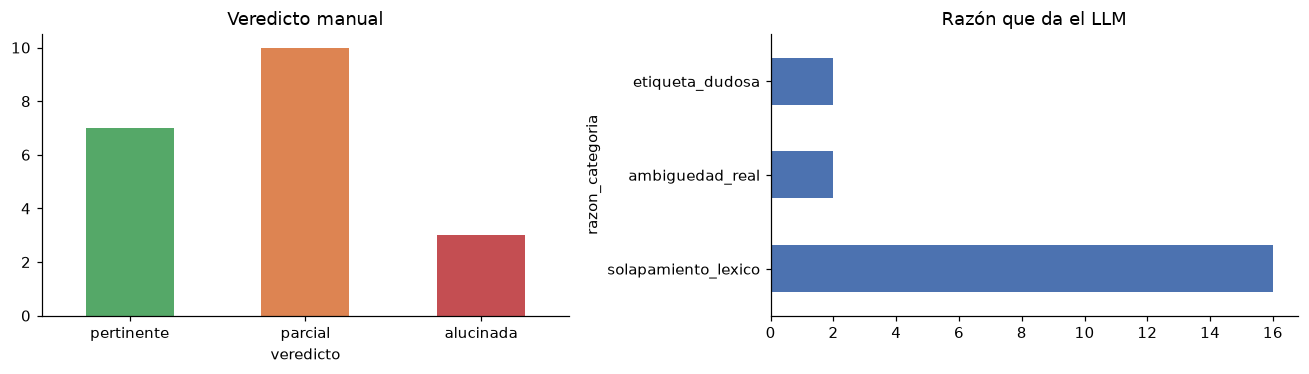

{'parcial': 10, 'pertinente': 7, 'alucinada': 3} · {'solapamiento_lexico': 16, 'ambiguedad_real': 2, 'etiqueta_dudosa': 2}
cita_falsa  con cita falsa  sin cita falsa
veredicto                                 
alucinada                1               2
parcial                  2               8
pertinente               1               6


In [26]:
# Revisión manual (entrada escrita a mano tras leer 4.6), atada a consulta_id y al texto revisado
revision = json.load(open(ART / "revision_manual.json"))
rev_df = pd.DataFrame(revision)
exp_df = exp_df.merge(rev_df[["consulta_id", "explicacion_revisada", "veredicto", "razon_categoria", "nota_revision"]],
                      on="consulta_id", how="left")
assert exp_df["veredicto"].notna().all(), "Falta el veredicto de alguna explicación"
assert (exp_df["explicacion_revisada"] == exp_df["explicacion"]).all(), "La revisión no corresponde a estas salidas"

# Tabla con cada explicación y su veredicto
with pd.option_context("display.max_colwidth", None):
    display(exp_df[["orden", "texto", "real", "predicha", "explicacion", "veredicto", "razon_categoria", "nota_revision"]])

# Conteo de veredictos y de categorías de razón
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.5))
exp_df["veredicto"].value_counts().reindex(["pertinente", "parcial", "alucinada"]).fillna(0).plot.bar(
    ax=ejes[0], color=["#55A868", "#DD8452", "#C44E52"], rot=0, title="Veredicto manual")
exp_df["razon_categoria"].value_counts().plot.barh(ax=ejes[1], color="#4C72B0", title="Razón que da el LLM")
plt.tight_layout(); plt.show()
print(exp_df["veredicto"].value_counts().to_dict(), "·", exp_df["razon_categoria"].value_counts().to_dict())
# ¿Coinciden las métricas automáticas con el juicio humano?
print(pd.crosstab(exp_df["veredicto"], exp_df["cita_falsa"].map({True: "con cita falsa", False: "sin cita falsa"})))

### 4.8 Razones proporcionadas por el LLM

**Veredicto de la revisión manual: 7 pertinentes, 10 parciales y 3 alucinadas de 20** (35 %, 50 % y 15 %). Con la
primera versión del prompt (P1 con T = 0.3 y 60 tokens), las mismas 20 consultas daban 3, 9 y 8: la calibración
completa **redujo las alucinaciones de 8 a 3**.

| Razón que da el LLM | Nº | Qué dice |
|---|---|---|
| **Solapamiento léxico** | 16 | «la palabra X de la consulta apunta a la clase predicha» — casi siempre cita una palabra real (*double charged*, *unblock*, *declined*, *PIN*) |
| **Ambigüedad real** | 2 | la consulta encaja en las dos clases (#10 *top-ups* sin especificar; #16 *disposable* en ambas) |
| **Etiqueta dudosa** | 2 | concluye por su cuenta que el clasificador acertó (#11 «How do I top up my card?»; #19 «How long can an EU transfer take?») |

Lo que sigue fallando, y cómo:

1. **Confundir cuál es la etiqueta y cuál la predicción** (#4 y #6, alucinadas; #5, #14 y #15, con la terminología
   mezclada). Con dos nombres de intención parecidos en el prompt, el modelo pierde cuál es cuál.
2. **Citar palabras que no están** (#12 *cash*; #13 *failed*; #20 *topping up*). La métrica automática detecta estos
   casos, pero también marca un falso positivo (#10: *top up* frente a *top-ups*).
3. **Añadir hechos** (#2: atribuye el doble cargo a un fraude, que la consulta no menciona).

La tabla cruzada de la celda anterior muestra el límite de la verificación automática: solo 1 de las 3 alucinadas
tiene una cita falsa detectable; las otras dos alucinan en el razonamiento, no en la cita. Por eso la validación
manual sigue siendo imprescindible.

**Etiquetas dudosas.** En al menos 6 de los 20 casos (#3, #7, #9, #11, #18 y #19) la predicción del clasificador es
tan razonable como la etiqueta del dataset o más. Con el prompt neutral (P3), el LLM lo dijo por sí mismo en dos
(#11 y #19); con el prompt que afirmaba «is WRONG» (P1) no lo había dicho en ninguno.

### 4.9 Conclusiones sobre el uso del LLM para interpretar el clasificador

- **La calibración funciona, y cada eje controla una cosa distinta.** La temperatura controla la *invención*: con
  T = 1.0 aparecen historias sobre el cliente que con T ≤ 0.3 no aparecen. La longitud (`max_new_tokens`) controla el
  *truncamiento*: 60 tokens cortan algunas respuestas, 150 no. La estructura controla la *fidelidad*: pedir citas
  exactas y dar dos ejemplos llevó las citas verificables de 1 a 8 de 8 y las falsas de 4 a 0.
- **Aun calibrado, un LLM de 7 B explica pero no garantiza verdad.** 7 de 20 explicaciones son plenamente
  pertinentes y 3 afirman algo falso. La fluidez sigue siendo el riesgo: todas suenan razonables. Falcon no ve los
  pesos ni las atenciones del clasificador, así que su explicación es una **conjetura *post hoc* a partir del texto**,
  no una explicación causal del modelo.
- **El encuadre del prompt importa.** Afirmar que la predicción era incorrecta (P1) llevaba al modelo a racionalizar;
  el prompt neutral le permitió señalar, en #11 y #19, que el clasificador probablemente acertó frente a una
  etiqueta dudosa.
- **Uso recomendado.** Como herramienta de **triaje** para un analista humano (hipótesis sobre grupos de errores, pares
  de clases confusas, sospechas de etiqueta dudosa) es útil y barato (≈ 3 s por explicación en un portátil). Como
  explicación final para un cliente o un auditor, no, salvo combinada con métodos que sí miran dentro del
  clasificador —SHAP (Lundberg y Lee, 2017) o gradientes integrados (Sundararajan et al., 2017)— y con verificación
  automática de las citas.

## 5. Conclusiones generales

1. **El Transformer resuelve bien la tarea.** DistilRoBERTa afinado alcanza **93.25 % de accuracy y 0.932 de F1
   macro** sobre 77 intenciones, al nivel de lo publicado con BERT-base (el doble de capas), con unos 117 ejemplos por
   clase y 8 minutos de entrenamiento, de forma reproducible. El EDA explicaba de antemano por qué hacía falta un modelo
   contextual: consultas cortas que comparten vocabulario y cuyo sentido lo deciden palabras que un preprocesado
   clásico eliminaría (*not*, *why*, *how*).
2. **Los errores tienen estructura, y el EDA la anticipaba a medias.** Se concentran en familias de intenciones con
   vocabulario compartido (68.3 % de los errores dentro de la misma familia; 9× más bigramas compartidos en los pares
   confusos; ρ = 0.28 entre similitud TF-IDF y confusión). El desbalance que también mostraba el EDA no mostró relación
   con el desempeño (ρ = −0.14, p = 0.21). El techo del modelo lo pone tanto la **calidad de las etiquetas** como la
   arquitectura.
3. **El LLM ayuda a pensar, no a explicar.** Con la calibración completa (T = 0.3, 150 tokens y un prompt neutral con
   citas y ejemplos), Falcon-7b-instruct pasó de 8 a 3 explicaciones alucinadas de 20, pero solo 7 fueron plenamente
   pertinentes. La calibración reduce la invención y el truncamiento; no convierte una conjetura en una explicación
   verificada. **La validación manual no es opcional.**
4. **El hallazgo más valioso lo dio la revisión humana:** descubrir que parte de los «errores» del clasificador son
   aciertos frente a etiquetas dudosas; el LLM solo lo notó cuando el prompt dejó de afirmar que la predicción era
   incorrecta.

**Ejemplos del experimento que lo sostienen:**

- *EDA → Transformer*: `verify_my_identity` y `why_verify_identity` comparten los bigramas *verify identity* e
  *identity check*, y el modelo las confundió 6 veces entre sí.
- *Transformer → calidad de las etiquetas*: «How do I top up my card?» está etiquetada como `transfer_into_account`; el
  modelo predijo `topping_up_by_card` con 98.9 % de confianza, y el LLM con el prompt neutral concluyó que la
  predicción era correcta (#11).
- *Calibración*: con T = 1.0 el LLM inventó que el cliente «escribió mal» *exchange rate*; con T = 0.3 no. Con P1 citó
  *card* en una consulta que no la contiene; con P3 citó *pending*, que sí está.
- *Limpieza*: «My card is not working» queda en «card working» al quitar stopwords; por eso el modelo recibe el texto
  original.

**Limitaciones.** Una sola semilla (la corrida se repitió y dio las mismas predicciones, pero no se midió la
variación entre semillas); la validación manual la hizo una sola persona; las 20 muestras son los errores **más
seguros** del modelo, no una muestra aleatoria, y concentran etiquetas dudosas, así que ni el 7/20 ni el 3/20 se pueden
extrapolar a los 208 errores; la calibración usó 8 consultas; la métrica automática de citas tiene falsos positivos;
y Falcon se ejecutó en `float16` en MPS, no cuantizado como sería en Colab, lo que puede variar sus salidas.

## 6. Referencias

- Almazrouei, E., Alobeidli, H., Alshamsi, A., et al. (2023). *The Falcon Series of Open Language
  Models*. arXiv:2311.16867.
- Brown, T., Mann, B., Ryder, N., et al. (2020). Language Models are Few-Shot Learners. *NeurIPS*.
- Casanueva, I., Temčinas, T., Gerz, D., Henderson, M., & Vulić, I. (2020). Efficient Intent
  Detection with Dual Sentence Encoders. *Proceedings of the 2nd Workshop on NLP for
  Conversational AI*, 38–45. arXiv:2003.04807. (Origen del dataset BANKING77.)
- Cui, Y., Jia, M., Lin, T.-Y., Song, Y., & Belongie, S. (2019). Class-Balanced Loss Based on Effective
  Number of Samples. *CVPR*.
- Dettmers, T., Pagnoni, A., Holtzman, A., & Zettlemoyer, L. (2023). QLoRA: Efficient Finetuning of
  Quantized LLMs. *NeurIPS*. (Cuantización NF4 de 4 bits.)
- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep
  Bidirectional Transformers for Language Understanding. *NAACL-HLT*.
- Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On Calibration of Modern Neural Networks.
  *ICML*.
- Holtzman, A., Buys, J., Du, L., Forbes, M., & Choi, Y. (2020). The Curious Case of Neural Text
  Degeneration. *ICLR*. (Muestreo *nucleus*/top-p y temperatura.)
- Ji, Z., Lee, N., Frieske, R., et al. (2023). Survey of Hallucination in Natural Language
  Generation. *ACM Computing Surveys*, 55(12).
- Liu, Y., Ott, M., Goyal, N., et al. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining
  Approach*. arXiv:1907.11692.
- Lundberg, S. M., & Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS*.
  (SHAP.)
- Northcutt, C., Jiang, L., & Chuang, I. (2021). Confident Learning: Estimating Uncertainty in Dataset
  Labels. *Journal of Artificial Intelligence Research*, 70, 1373–1411.
- Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). *DistilBERT, a distilled version of BERT:
  smaller, faster, cheaper and lighter*. arXiv:1910.01108.
- Sennrich, R., Haddow, B., & Birch, A. (2016). Improving Neural Machine Translation Models with
  Monolingual Data. *ACL*. (Back-translation.)
- Sundararajan, M., Taly, A., & Yan, Q. (2017). Axiomatic Attribution for Deep Networks. *ICML*.
  (Gradientes integrados.)
- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). Attention Is All You Need. *NeurIPS*.
- Wei, J., & Zou, K. (2019). EDA: Easy Data Augmentation Techniques for Boosting Performance on Text
  Classification Tasks. *EMNLP-IJCNLP*.
- Wolf, T., Debut, L., Sanh, V., et al. (2020). Transformers: State-of-the-Art Natural Language
  Processing. *EMNLP: System Demonstrations*.
- Ying, C., & Thomas, S. (2022). Label Errors in BANKING77. *Proceedings of the Third Workshop on
  Insights from Negative Results in NLP*, ACL.
- Documentación de Hugging Face: `PolyAI/banking77`, ficha de `distilbert/distilroberta-base`,
  `tiiuae/falcon-7b-instruct`, *Text generation strategies*.

## 7. Anexo: exportación de resultados

Todos los resultados se guardan en `artefactos/` para cargarlos en la base de datos del
proyecto (tablas `DistilRoBERTa_*` en Supabase) y publicarlos en
<https://distilroberta.iagentek.com.mx>. Así, cada cifra de la web sale de esta ejecución.

In [27]:
from datetime import datetime

# Identificador de esta ejecución: fecha y hora
CORRIDA_ID = datetime.now().strftime("%Y-%m-%dT%H-%M")
def guardar(nombre, obj):
    json.dump(obj, open(ART / nombre, "w"), indent=1, ensure_ascii=False, default=float)

# Hiperparámetros y métricas globales de la corrida
guardar("corrida.json", {
    "id": CORRIDA_ID, "modelo_base": MODELO_BASE, "llm": LLM_ID, "dispositivo": DEVICE,
    "hiperparametros": {"learning_rate": 5e-5, "epocas_max": 8, "lote": 32, "max_length": MAX_LEN,
                        "warmup_ratio": 0.1, "weight_decay": 0.01, "seed": SEED,
                        "mejor_epoca": int(curva.loc[curva.eval_f1_macro.idxmax(), "epoch"]),
                        "config_llm": CONFIG_ELEGIDA, "prompt_llm": PROMPT_ELEGIDO,
                        **{f"llm_{k}": v for k, v in CONFIGS[CONFIG_ELEGIDA].items()}},
    "accuracy": ACCURACY, "f1_macro": F1_MACRO, "n_train": len(tr_df), "n_val": len(val_df),
    "n_test": len(test_df), "duracion_entrenamiento_s": DURACION_ENTRENAMIENTO})

# Las 77 clases con su conteo por partición
guardar("clases.json", [{"id": i, "nombre": n, "nombre_legible": legible(n),
                         "n_train": int(conteo.loc[n, "train"]), "n_test": int(conteo.loc[n, "test"])}
                        for i, n in enumerate(ETIQUETAS)])

# Las 13 083 consultas con su texto limpio, longitudes y tokens (id de prueba = 100000 + índice)
consultas = pd.concat([
    train_df.assign(particion="train", id=range(len(train_df))),
    test_df.assign(particion="test", id=[100000 + i for i in range(len(test_df))]),
])[["id", "particion", "text", "texto_limpio", "label", "n_caracteres", "n_palabras", "n_tokens"]]
consultas.to_csv(ART / "consultas.csv", index=False)

# Estadísticas descriptivas y n-gramas del análisis exploratorio
est = []
for part, df in (("train", train_df), ("test", test_df)):
    for met in ("n_caracteres", "n_palabras", "n_tokens"):
        d = df[met].describe()
        est.append({"metrica": met, "particion": part, "count": int(d["count"]), "mean": d["mean"], "std": d["std"],
                    "min": d["min"], "q1": d["25%"], "mediana": d["50%"], "q3": d["75%"], "max": d["max"]})
ngr = [{"tipo": t, "rango": r + 1, "ngrama": f.ngrama, "frecuencia": int(f.frecuencia)}
       for t, df in (("palabra", top_palabras), ("bigrama", top_bigramas), ("trigrama", top_trigramas))
       for r, f in enumerate(df.itertuples())]
guardar("eda.json", {"estadisticas": est, "ngramas": ngr, "balance": {k: v for k, v in balance.items()
                                                                        if k != "test: valores distintos"}})

# Curvas de entrenamiento, métricas por clase y matriz de confusión dispersa
guardar("entrenamiento.json", curva.to_dict("records"))
guardar("metricas_clase.json", [{"clase_id": ID[n], "precision": r["precision"], "recall": r["recall"],
                                 "f1": r["f1-score"], "soporte": int(r["support"]), "errores": int(r["errores"]),
                                 "categoria": "mejor" if n in mejores.index else "peor" if n in peores.index else None}
                                for n, r in por_clase.iterrows()])
guardar("confusion.json", [[int(i), int(j), int(cm[i, j])] for i in range(N_CLASES) for j in range(N_CLASES) if cm[i, j]])

# Predicción, confianza y top-5 de cada consulta de prueba
top5 = np.argsort(-probs, axis=1)[:, :5]
pd.DataFrame({"consulta_id": [100000 + i for i in range(len(test_df))], "clase_pred_id": y_pred,
              "confianza": confianza.round(5),
              "top5": [json.dumps([{"clase_id": int(c), "prob": round(float(probs[k, c]), 5)} for c in top5[k]])
                       for k in range(len(test_df))]}).to_csv(ART / "predicciones.csv", index=False)

# Calibración (decodificación y estructura) y explicaciones del LLM
calibracion = pd.concat([dec_df, est_df[est_df["prompt"] != "P1"]], ignore_index=True)
calibracion["elegida"] = (calibracion["config"] == CONFIG_ELEGIDA) & (calibracion["prompt"] == PROMPT_ELEGIDO)
guardar("calibracion.json", [{**r, "consulta_id": int(r["consulta_id"]),
                              "parametros": {**CONFIGS[r["config"]], "prompt": r["prompt"]}}
                             for r in calibracion.to_dict("records")])
guardar("explicaciones.json", [{**r, "consulta_id": int(r["consulta_id"]),
                                "parametros": {**CONFIGS[CONFIG_ELEGIDA], "prompt": PROMPT_ELEGIDO}}
                               for r in exp_df.to_dict("records")])
print("Corrida", CORRIDA_ID, "→", sorted(p.name for p in ART.iterdir()))

Corrida 2026-09-26T03-06 → ['calibracion.json', 'clases.json', 'confusion.json', 'consultas.csv', 'corrida.json', 'cumplimiento.json', 'eda.json', 'entregables.json', 'entrenamiento.json', 'explicaciones.json', 'explicaciones_crudas.json', 'metricas_clase.json', 'predicciones.csv', 'revision_manual.json', 'simulacion_llm.json']
